---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

---

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.


In [1]:
#@title Identificação
Nome_1 = "Ulisses Ribeiro Abreu" #@param {type:"string"}
RM_1 = "562230" #@param {type:"string"}
Nome_2 = "Arthur Berlofa Bosi" #@param {type:"string"}
RM_2 = "564438" #@param {type:"string"}
Nome_3 = "Davi Melo Muniz" #@param {type:"string"}
RM_3 = "562828" #@param {type:"string"}
Nome_4 = "Mateus Saavedra" #@param {type:"string"}
RM_4 = "563266" #@param {type:"string"}
Nome_5 = "Danilo dos Santos" #@param {type:"string"}
RM_5 = "561657" #@param {type:"string"}


---

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

In [2]:
# Dependências de modelagem
import sys
!{sys.executable} -m pip install -q xgboost lightgbm optuna

In [3]:
# Imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Base: https://www.kaggle.com/datasets/sergionefedov/so-paulo-real-estate-sales-and-rentals-2020-2026

# Modelagem
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, cross_val_predict,
    GridSearchCV, learning_curve,
)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
import pickle

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEMENTE = 42
pd.set_option('display.max_columns', 100)

def eixo_em_milhoes(ax, eixo='x'):
    """Rótulos em milhões de reais, com a faixa abaixo de R$ 1 mi destacada."""
    limite = ax.get_xlim() if eixo == 'x' else ax.get_ylim()
    maximo = int(limite[1] // 1e6)
    # Rótulo a cada 2 mi, ou a cada 1 mi se o eixo for curto
    passo = 2 if maximo > 4 else 1
    milhoes = list(range(2, maximo + 1, passo))
    # A faixa abaixo de 1 mi ganha um rótulo só, no meio dela
    posicoes = [0.5e6] + [m * 1e6 for m in milhoes]
    rotulos = ['menos de R$ 1 mi'] + [f'R$ {m} mi' for m in milhoes]
    # Pinta a faixa de cinza e mantém os limites originais do eixo
    if eixo == 'x':
        ax.axvspan(0, 1e6, color='gray', alpha=0.08)
        ax.set_xticks(posicoes, rotulos)
        ax.set_xlim(limite)
    else:
        ax.axhspan(0, 1e6, color='gray', alpha=0.08)
        ax.set_yticks(posicoes, rotulos)
        ax.set_ylim(limite)

def eixo_residuo_em_milhoes(ax):
    """Resíduos positivos e negativos em milhões de reais."""
    # Sinal de + ou − pra mostrar se o modelo errou pra cima ou pra baixo
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: '0' if v == 0 else f"{'+' if v > 0 else '−'}R$ {abs(v) / 1e6:.0f} mi"))


**Resposta do aluno — Exercício 1**

Descreva o problema, a base, a variável-alvo e o critério de sucesso.

### **1.1 Contexto: quanto vale um imóvel de revenda em São Paulo?**

Precificar apartamentos usados em São Paulo a partir das suas características.

- **Pergunta:** qual o preço de mercado de um imóvel, dadas localização, área, padrão e infraestrutura?
- **Por que supervisionado:** Observamos o preço de 50 mil imóveis, e o preço depende de interações não lineares que modelos de árvore capturam bem.
- **Alvo:** Nosso problema é de **regressão** e o preço de mercado de um imóvel é o que queremos descobrir.

### **1.2 Base de dados: origem, dimensões e dicionário**

 `secondary_sales.csv` do dataset *São Paulo Real Estate Sales and Rentals 2020-2026*. Cada linha é um imóvel de revenda anunciado em SP entre 2020 e 2026.

In [4]:
# Importação da base
df_bruto = pd.read_csv('data/secondary_sales.csv')

print(f"Dimensões iniciais: {df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas")
print("Fonte: Kaggle — 'São Paulo Real Estate Sales and Rentals 2020-2026', arquivo secondary_sales.csv")
display(df_bruto.head(3))

Dimensões iniciais: 50000 linhas x 37 colunas
Fonte: Kaggle — 'São Paulo Real Estate Sales and Rentals 2020-2026', arquivo secondary_sales.csv


,id,date_listed,bairro,zona,tier,lat,lon,property_type,dorms,area_util_m2,area_total_m2,floor,total_floors,year_built,condition,sun_facing,vagas_garagem,seguranca_24h,varanda_gourmet,lazer_completo,in_eixo_plano_diretor,transit_station,transit_line,transit_distance_min,transit_distance_type,to_paulista_km,to_faria_lima_km,price_brl,price_per_m2_util_brl,price_usd,price_per_m2_util_usd,condominio_brl_monthly,iptu_brl_annual,brl_usd_rate_at_listing,selic_rate_at_listing,mortgage_rate_at_listing,ipca_yoy_at_listing
0,S000001,2024-11-23,Saúde,Zona Sul,premium,-23.61819,-46.64459,2_dorm,2,80.5,101.0,3,4,2022,reformado,face_oeste,1,True,True,False,True,Saúde,Linha 1,4,walk,6.43,4.97,1285000,15956,210586,2616,1139,8542,6.1,11.25,14.25,4.8
1,S000002,2021-01-16,Campo Belo,Zona Sul,premium,-23.62030,-46.66071,2_dorm,2,87.1,111.9,19,25,1982,seminovo,face_sul,1,True,False,False,False,Brás,Linha 3,57,bus,6.57,4.33,839000,9629,161323,1852,979,5579,5.2,2.00,5.00,8.4
2,S000003,2024-03-27,Jardim Paulistano,Zona Oeste,luxury,-23.58192,-46.68370,2_dorm,2,77.6,98.9,22,25,2011,reformado,face_leste,2,True,True,False,False,Faria Lima,Linha 4,13,bus,3.61,0.82,1822000,23475,350341,4514,1454,12115,5.2,10.50,13.50,4.0


In [5]:
# Criação de um dicionario pra inspecionar os tipos das colunas, uniques e exemplos
# (Pra evitar plotar head e tail e ja verificar possiveis incongruências mais básicas)
dicionario = pd.DataFrame({
    'coluna': df_bruto.columns,
    'tipo': df_bruto.dtypes.astype(str).values,
    'n_unicos': [df_bruto[c].nunique() for c in df_bruto.columns],
    'exemplo': [df_bruto[c].iloc[0] for c in df_bruto.columns],
})
print(f"Dicionário de dados ({len(dicionario)} colunas):")
display(dicionario)

Dicionário de dados (37 colunas):


,coluna,tipo,n_unicos,exemplo
0,id,object,50000,S000001
1,date_listed,object,2311,2024-11-23
2,bairro,object,85,Saúde
3,zona,object,5,Zona Sul
4,tier,object,4,premium
5,lat,float64,19076,-23.61819
6,lon,float64,22938,-46.64459
7,property_type,object,5,2_dorm
8,dorms,int64,5,2
9,area_util_m2,float64,2336,80.5


### **1.3 Critério de sucesso: escolhemos o RMSE como nossa métrica principal**

**RMSE** em reais: penaliza mais os erros grandes, que são os mais caros em precificação, e fica na unidade do alvo. MAE e R² são auxiliares.

In [6]:
# Estatísticas descritivas do preço

print("Estatísticas descritivas do preço dos imóveis:")
print(df_bruto['price_brl'].describe().apply(lambda v: f"{v:,.0f}"))
print(f"\nAssimetria (skewness): {df_bruto['price_brl'].skew():.2f}")

Estatísticas descritivas do preço dos imóveis:
count       50,000
mean       775,535
std        741,563
min         36,000
25%        297,000
50%        538,000
75%        979,000
max      8,713,000
Name: price_brl, dtype: object

Assimetria (skewness): 2.55


#### **1.3.1 Distribuição do preço**

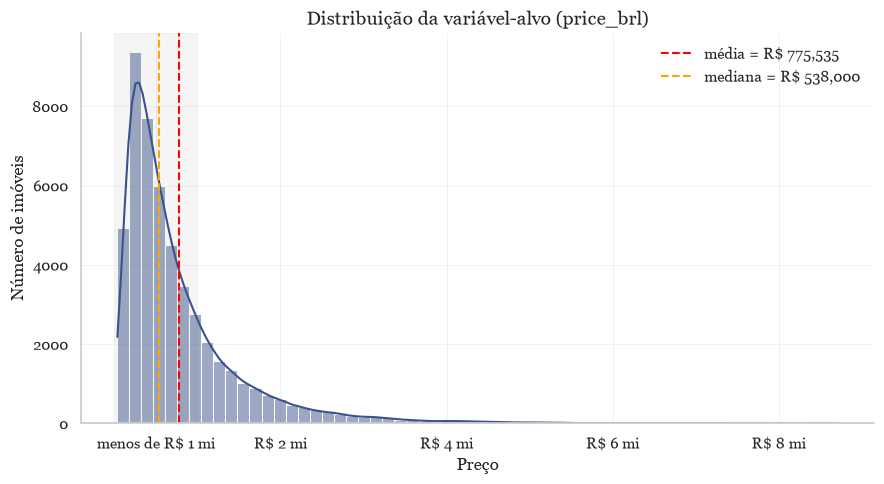

In [7]:
# Distribuição da variável alvo
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_bruto['price_brl'], kde=True, bins=60, ax=ax, color='#3b528b')
ax.axvline(df_bruto['price_brl'].mean(), color='red', linestyle='--',
           label=f"média = R$ {df_bruto['price_brl'].mean():,.0f}")
ax.axvline(df_bruto['price_brl'].median(), color='orange', linestyle='--',
           label=f"mediana = R$ {df_bruto['price_brl'].median():,.0f}")
ax.set_title('Distribuição da variável-alvo (price_brl)')
ax.set_xlabel('Preço')
ax.set_ylabel('Número de imóveis')
eixo_em_milhoes(ax, 'x')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação.** O preço é bem assimétrico: a média (R\$ 776 mil) fica acima da mediana (R\$ 538 mil), puxada por poucos imóveis muito caros, e 75,8% dos anúncios custam menos de R\$ 1 milhão. Por isso usamos o RMSE em reais para medir o erro, mas treinamos o modelo em escala logarítmica (3.4).

**Resposta do aluno — Exercício 2**

Explique as decisões de data wrangling e interprete os principais achados da análise exploratória.

### **2.1 Diagnóstico: ausências, duplicidades e valores impossíveis**

Tipos, ausências, duplicidades, rótulos e combinações impossíveis entre colunas.

In [8]:
# Diagnóstico mais aprofundado da base
print("Tipos de dados:\n")
print(df_bruto.dtypes.value_counts())

# Verificação dos nulos
nulos = df_bruto.isnull().sum()
print(f"\nTotal de valores ausentes na base: {nulos.sum()}")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhuma coluna com valores faltantes.")

# Linhas totalmente duplicadas
print(f"\nLinhas duplicadas por id': {df_bruto['id'].duplicated().sum()}")
print(f"Linhas 100% duplicadas: {df_bruto.duplicated().sum()}")

# Verificação de valores inconsistentes
df_bruto['date_listed'] = pd.to_datetime(df_bruto['date_listed'])
_anomalia_ano = (df_bruto['year_built'] > df_bruto['date_listed'].dt.year).sum()
print(f"\nValor impossível: {_anomalia_ano} linhas ({_anomalia_ano/len(df_bruto):.1%}) com "
      f"ano de construção depois ao ano do anúncio (um imóvel de REVENDA não pode ter sido "
      f"construído depois de anunciado).")

# Verificação de valores inconsistentes
print(f"Área total menor que a área útil: {(df_bruto['area_total_m2'] < df_bruto['area_util_m2']).sum()} linhas")
print(f"Andar acima do total de andares: {(df_bruto['floor'] > df_bruto['total_floors']).sum()} linhas")
print(f"Preços não positivos: {(df_bruto['price_brl'] <= 0).sum()} linhas")

# Inspeção de variáveis que são função direta da alvo
razao_iptu = df_bruto['iptu_brl_annual'] / df_bruto['price_brl']
print(f"\nIPTU/preço: média {razao_iptu.mean():.3%}, coef. de variação "
      f"{razao_iptu.std() / razao_iptu.mean():.2%}, correlação "
      f"{df_bruto['iptu_brl_annual'].corr(df_bruto['price_brl']):.4f} -> IPTU é fração fixa do preço")
razao_cond = df_bruto['condominio_brl_monthly'] / df_bruto['price_brl']

# Verificação de inconsistencia no condomínio em relação ao preço
print(f"Condomínio/preço: coef. de variação {razao_cond.std() / razao_cond.mean():.1%} -> "
      "acompanha área e padrão, mas não é fração do preço ")

# Studios com 0 dormitórios não são anomalias
print(f"Studios com dorms=0: {((df_bruto['property_type'] == 'studio') & (df_bruto['dorms'] == 0)).sum()} "
      f"de {(df_bruto['property_type'] == 'studio').sum()} (não é anomalia)")

# Verificação dos rótulos inconsistentes 
print("\nCategorias por variável categórica (checagem de rótulos inconsistentes):")
for col in ['zona', 'tier', 'property_type', 'condition', 'sun_facing', 'transit_distance_type']:
    print(f"  {col} ({df_bruto[col].nunique()}): {sorted(df_bruto[col].unique().tolist())}")
print(f"  bairro: {df_bruto['bairro'].nunique()} categorias (alta cardinalidade)")

Tipos de dados:

int64      12
object     11
float64    10
bool        4
Name: count, dtype: int64

Total de valores ausentes na base: 0
Nenhuma coluna com valores faltantes.

Linhas duplicadas por id': 0
Linhas 100% duplicadas: 0

Valor impossível: 2171 linhas (4.3%) com ano de construção depois ao ano do anúncio (um imóvel de REVENDA não pode ter sido construído depois de anunciado).
Área total menor que a área útil: 0 linhas
Andar acima do total de andares: 0 linhas
Preços não positivos: 0 linhas

IPTU/preço: média 0.665%, coef. de variação 0.10%, correlação 1.0000 -> IPTU é fração fixa do preço
Condomínio/preço: coef. de variação 56.1% -> acompanha área e padrão, mas não é fração do preço 
Studios com dorms=0: 4422 de 4422 (não é anomalia)

Categorias por variável categórica (checagem de rótulos inconsistentes):
  zona (5): ['Centro', 'Zona Leste', 'Zona Norte', 'Zona Oeste', 'Zona Sul']
  tier (4): ['affordable', 'luxury', 'mid', 'premium']
  property_type (5): ['1_dorm', '2_dorm'

### **2.2 Tratamento: limpeza, novas variáveis e colunas descartadas**

Aqui contém apenas as transformações que não aprendem com os dados. As Outras ficam no pipeline 3.4.

In [9]:
# Tratamento e limpeza da base, só com mudanças que não acontecem naturalmente com o aprendizado do modelo
df = df_bruto.copy()

antes = len(df)
df['listing_year'] = df['date_listed'].dt.year
df = df[df['year_built'] <= df['listing_year']].copy()
print(f"Remoção de {antes - len(df)} linhas com ano de construção posterior ao anúncio.")

df['building_age'] = df['listing_year'] - df['year_built']
print("Criação de listing_year (ano do anúncio) e building_age (idade do imóvel no anúncio).")

colunas_bool = ['seguranca_24h', 'varanda_gourmet', 'lazer_completo', 'in_eixo_plano_diretor']
df[colunas_bool] = df[colunas_bool].astype(int)
print(f"Conversão de booleanos pra inteiros: {colunas_bool}")

colunas_para_remover = [
    'id', 'date_listed',
    'price_per_m2_util_brl', 'price_usd', 'price_per_m2_util_usd',
    'brl_usd_rate_at_listing', 'selic_rate_at_listing',
    'mortgage_rate_at_listing', 'ipca_yoy_at_listing',
    'transit_station', 'iptu_brl_annual',
]
df = df.drop(columns=colunas_para_remover)
print(f"Remoção de {len(colunas_para_remover)} colunas, sendo elas: {colunas_para_remover}")

Remoção de 2171 linhas com ano de construção posterior ao anúncio.
Criação de listing_year (ano do anúncio) e building_age (idade do imóvel no anúncio).
Conversão de booleanos pra inteiros: ['seguranca_24h', 'varanda_gourmet', 'lazer_completo', 'in_eixo_plano_diretor']
Remoção de 11 colunas, sendo elas: ['id', 'date_listed', 'price_per_m2_util_brl', 'price_usd', 'price_per_m2_util_usd', 'brl_usd_rate_at_listing', 'selic_rate_at_listing', 'mortgage_rate_at_listing', 'ipca_yoy_at_listing', 'transit_station', 'iptu_brl_annual']


### **2.3 Análise exploratória:**

Distribuição do alvo e sua relação com zona, área e variáveis numéricas.

#### **2.3.1 Distribuição de log (1 + preço)**

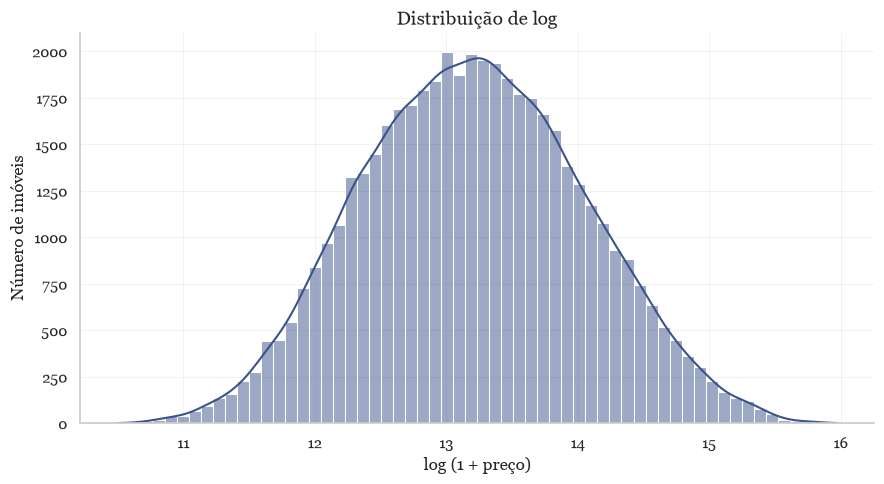

In [10]:
# Distribuição da variável alvo
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(np.log1p(df['price_brl']), kde=True, bins=60, ax=ax, color='#3b528b')
ax.set_title('Distribuição de log')
ax.set_xlabel('log (1 + preço)')
ax.set_ylabel('Número de imóveis')
plt.tight_layout()
plt.show()

**Interpretação.** Em escala logarítmica, o preço fica próximo de uma distribuição simétrica. É isso que justifica treinar o modelo com o log do preço: os imóveis caros deixam de dominar o aprendizado.

#### **2.3.2 Preço por zona**

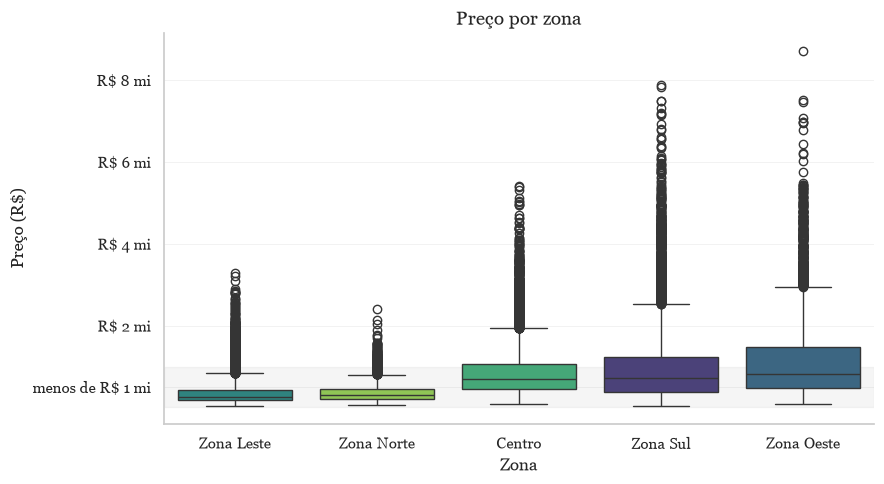

Mediana de preço por zona (R$):
zona
Zona Leste    266,000
Zona Norte    315,000
Centro        690,000
Zona Sul      709,000
Zona Oeste    816,000
Name: price_brl, dtype: object


In [11]:
# Preço por zona, organizado pela mediana
ordem_zona = df.groupby('zona')['price_brl'].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='zona', y='price_brl', order=ordem_zona, hue='zona',
            legend=False, ax=ax, palette='viridis')

ax.set_title('Preço por zona')
ax.set_xlabel('Zona')
ax.set_ylabel('Preço (R$)')
eixo_em_milhoes(ax, 'y')
plt.tight_layout()
plt.show()

print("Mediana de preço por zona (R$):")
print(df.groupby('zona')['price_brl'].median().reindex(ordem_zona).apply(lambda v: f"{v:,.0f}"))

**Interpretação.** A localização separa bem os preços: a mediana vai de R\$ 266 mil na Zona Leste a R\$ 816 mil na Zona Oeste. Zona Sul e Zona Oeste concentram os imóveis mais caros (pontos acima das caixas, até R\$ 8,7 mi). Esses valores altos são imóveis de luxo reais, não erros, e por isso foram mantidos.

#### **2.3.3 Área útil vs. preço**

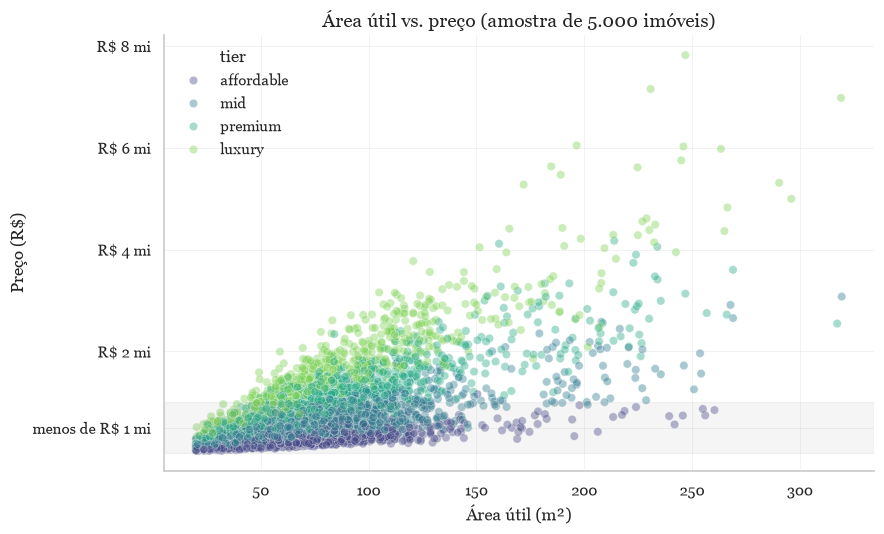

In [12]:
# Área útil vs o preço com a cor de acordo com o padrão do imóvel
ordem_tier = ['affordable', 'mid', 'premium', 'luxury']
amostra_grafico = df.sample(n=5000, random_state=SEMENTE)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=amostra_grafico, x='area_util_m2', y='price_brl', hue='tier',
                hue_order=ordem_tier, alpha=0.4, ax=ax, palette='viridis')
ax.set_title('Área útil vs. preço (amostra de 5.000 imóveis)')
ax.set_xlabel('Área útil (m²)')
ax.set_ylabel('Preço (R$)')
eixo_em_milhoes(ax, 'y')
plt.tight_layout()
plt.show()

**Interpretação.** O preço cresce com a área útil, mas imóveis do mesmo tamanho variam muito conforme o padrão: as cores formam camadas, com os de luxo bem acima dos econômicos. Área e padrão, juntos, explicam boa parte do preço.

#### **2.3.4 Matriz de correlação**

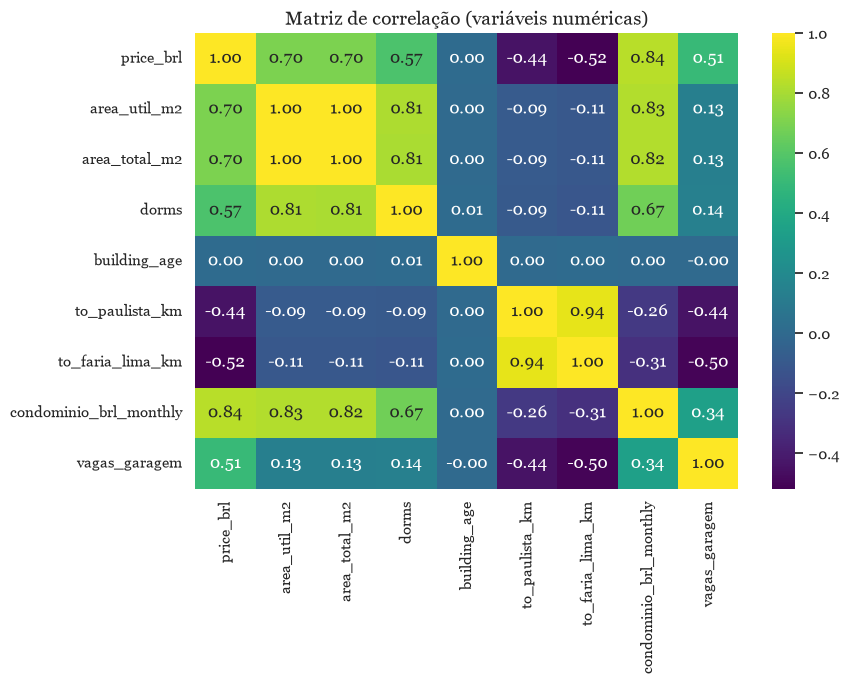

Correlação de cada variável numérica com price_brl:
condominio_brl_monthly    0.835
area_util_m2              0.702
area_total_m2             0.699
dorms                     0.571
vagas_garagem             0.507
building_age              0.004
to_paulista_km           -0.442
to_faria_lima_km         -0.518
Name: price_brl, dtype: float64


In [13]:
# Correlação entre as variáveis numéricas
colunas_correlacao = ['price_brl', 'area_util_m2', 'area_total_m2', 'dorms', 'building_age',
                 'to_paulista_km', 'to_faria_lima_km', 'condominio_brl_monthly', 'vagas_garagem']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[colunas_correlacao].corr(), annot=True, fmt='.2f', cmap='viridis', ax=ax)
ax.set_title('Matriz de correlação (variáveis numéricas)')
plt.tight_layout()
plt.show()

print("Correlação de cada variável numérica com price_brl:")
print(df[colunas_correlacao].corr()['price_brl'].drop('price_brl').sort_values(ascending=False).round(3))

**Interpretação.** As variáveis mais ligadas ao preço são o condomínio (0,84) e a área útil (0,70). As distâncias até a Faria Lima (−0,52) e a Paulista (−0,44) têm correlação negativa: quanto mais longe do centro financeiro, mais barato. A idade do imóvel quase não se relaciona com o preço (0,00). Área útil e área total são praticamente iguais (1,00), mas modelos de árvore lidam bem com essa redundância.

### **2.4 Base final e as etapas reservadas ao pipeline**

Dimensões finais da base e uma segunda verificação de possíveis ausências ou duplicidades.

As etapas que **aprendem com os dados** ficam fora desta base e são ajustadas só no treino, dentro do pipeline na seção 3.4:

| Etapa | Variáveis | Transformação |
|---|---|---|
| Imputação | numéricas | `SimpleImputer(strategy='median')` |
| One-hot encoding | `zona`, `tier`, `property_type`, `condition`, `sun_facing`, `transit_line`, `transit_distance_type` | `OneHotEncoder(drop='first', handle_unknown='ignore')` |
| Target encoding | `bairro` (85 categorias) | média suavizada do alvo, calculada dentro da validação cruzada |
| Alvo | `price_brl` | $\log(1+y)$ via `TransformedTargetRegressor` |

In [14]:
# Base final após as camadas de tratamento
print(f"Dimensões depois do tratamento: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Valores ausentes depois do tratamento: {df.isnull().sum().sum()}")
print(f"Duplicidades depois do tratamento: {df.duplicated().sum()}")
display(df.head(3))

Dimensões depois do tratamento: 47829 linhas x 28 colunas
Valores ausentes depois do tratamento: 0
Duplicidades depois do tratamento: 0


,bairro,zona,tier,lat,lon,property_type,dorms,area_util_m2,area_total_m2,floor,total_floors,year_built,condition,sun_facing,vagas_garagem,seguranca_24h,varanda_gourmet,lazer_completo,in_eixo_plano_diretor,transit_line,transit_distance_min,transit_distance_type,to_paulista_km,to_faria_lima_km,price_brl,condominio_brl_monthly,listing_year,building_age
0,Saúde,Zona Sul,premium,-23.61819,-46.64459,2_dorm,2,80.5,101.0,3,4,2022,reformado,face_oeste,1,1,1,0,1,Linha 1,4,walk,6.43,4.97,1285000,1139,2024,2
1,Campo Belo,Zona Sul,premium,-23.62030,-46.66071,2_dorm,2,87.1,111.9,19,25,1982,seminovo,face_sul,1,1,0,0,0,Linha 3,57,bus,6.57,4.33,839000,979,2021,39
2,Jardim Paulistano,Zona Oeste,luxury,-23.58192,-46.68370,2_dorm,2,77.6,98.9,22,25,2011,reformado,face_leste,2,1,1,0,0,Linha 4,13,bus,3.61,0.82,1822000,1454,2024,13


**Resposta do aluno — Exercício 3**

Justifique as variáveis escolhidas, o particionamento dos dados, a validação cruzada e as métricas.

### **3.1 Variáveis preditoras, alvo e exclusões por vazamento**

Variáveis agrupadas pelo tratamento que recebem no pipeline.

In [15]:
# Definição das variáveis X e y
ALVO = 'price_brl'

COLUNAS_NUMERICAS = [
    'lat', 'lon', 'area_util_m2', 'area_total_m2', 'floor', 'total_floors',
    'dorms', 'vagas_garagem', 'year_built', 'building_age', 'listing_year',
    'transit_distance_min', 'to_paulista_km', 'to_faria_lima_km',
    'seguranca_24h', 'varanda_gourmet', 'lazer_completo', 'in_eixo_plano_diretor',
]
COLUNAS_CUSTO = ['condominio_brl_monthly']
CATEGORICAS_BAIXA_CARD = ['zona', 'tier', 'property_type', 'condition', 'sun_facing',
                     'transit_line', 'transit_distance_type']
CATEGORICAS_ALTA_CARD = ['bairro']
COLUNAS_X = COLUNAS_NUMERICAS + COLUNAS_CUSTO + CATEGORICAS_BAIXA_CARD + CATEGORICAS_ALTA_CARD

X = df[COLUNAS_X].copy()
y = df[ALVO].copy()

print(f"X: {X.shape} | Y: {y.shape}")
print(f"Numéricas ({len(COLUNAS_NUMERICAS)}): {COLUNAS_NUMERICAS}")
print(f"Custos com imputação ({len(COLUNAS_CUSTO)}): {COLUNAS_CUSTO}\n")
print(f"Categóricas de baixa cardinalidade ({len(CATEGORICAS_BAIXA_CARD)}): {CATEGORICAS_BAIXA_CARD}")
print(f"Categórica de alta cardinalidade: {CATEGORICAS_ALTA_CARD} ({X['bairro'].nunique()} categorias)")

X: (47829, 27) | Y: (47829,)
Numéricas (18): ['lat', 'lon', 'area_util_m2', 'area_total_m2', 'floor', 'total_floors', 'dorms', 'vagas_garagem', 'year_built', 'building_age', 'listing_year', 'transit_distance_min', 'to_paulista_km', 'to_faria_lima_km', 'seguranca_24h', 'varanda_gourmet', 'lazer_completo', 'in_eixo_plano_diretor']
Custos com imputação (1): ['condominio_brl_monthly']

Categóricas de baixa cardinalidade (7): ['zona', 'tier', 'property_type', 'condition', 'sun_facing', 'transit_line', 'transit_distance_type']
Categórica de alta cardinalidade: ['bairro'] (85 categorias)


### **3.2 Teste de Performance: divisão 80/20 e KFold com 5 folds**

Divisão 80/20 com `random_state=42` e `KFold(5)` dentro do treino com os mesmos folds para os três modelos.

In [16]:
# Comparação entre Treino/teste e KFold
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=SEMENTE
)
print(f"D_treino: {X_treino.shape} | D_teste: {X_teste.shape} (80/20, random_state={SEMENTE})")

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMENTE)
METRICA_CV = 'neg_root_mean_squared_error'  # RMSE
print(f"Validação cruzada: KFold"
      " dentro de D_treino (os mesmos folds para os três algoritmos).")

D_treino: (38263, 27) | D_teste: (9566, 27) (80/20, random_state=42)
Validação cruzada: KFold dentro de D_treino (os mesmos folds para os três algoritmos).


### **3.3 Métricas utilizadas:**

- **RMSE** (principal): erro típico em R\$. Quanto menor, melhor.
- **MAE:** erro médio em R\$, menos sensível a extremos.
- **R²:** Quanto % o modelo consegue explicar a variância do preço.

### **3.4 Pipeline de pré-processamento**

**Por que treinar em escala logarítmica.** Os preços vão de R\$ 36 mil a R\$ 8,7 milhões. Em reais, o modelo ia se preocupar quase que só com os imóveis caros, ja em log, ele passa a medir o erro em **percentual**, e errar 10% num imóvel de R\$ 300 mil pesa o mesmo que errar 10% num de R\$ 3 milhões. O `TransformedTargetRegressor` converte o preço para log no treino e o devolve em reais na previsão.

In [17]:
# Pipeline de pré processamento
class CodificadorBairro(BaseEstimator, TransformerMixin):
    """Target encoding suavizado, reajustado em cada fold da validação cruzada."""
    def __init__(self, suavizacao=50):
        self.suavizacao = suavizacao

    def fit(self, X, y):
        serie = X.iloc[:, 0]
        y = np.asarray(y, dtype=float)

        # Média geral do preço, usada como referência pros bairros com poucos imóveis
        self.media_global_ = float(y.mean())
        estatisticas = pd.DataFrame({'cat': serie.values, 'y': y}).groupby('cat')['y'].agg(['mean', 'count'])

        # Mistura a média do bairro com a geral: quanto menos imóveis no bairro, mais perto da geral
        estatisticas['codificado'] = (
            estatisticas['count'] * estatisticas['mean'] + self.suavizacao * self.media_global_
        ) / (estatisticas['count'] + self.suavizacao)
        # Guarda o valor de cada bairro pra usar no transform
        self.mapa_ = estatisticas['codificado'].to_dict()
        return self

    def transform(self, X):
        serie = X.iloc[:, 0]
        
        # Bairro que não apareceu no treino recebe a média geral
        return serie.map(self.mapa_).fillna(self.media_global_).to_numpy().reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(['bairro_codificado'])

def criacao_preprocessador():
    return ColumnTransformer(
        transformers=[
            # Numéricas: campos vazios viram a mediana
            ('imputacao', SimpleImputer(strategy='median'), COLUNAS_NUMERICAS + COLUNAS_CUSTO),
            # Bairro: vira a média de preço suavizada
            ('codif_bairro', CodificadorBairro(suavizacao=50), CATEGORICAS_ALTA_CARD),
            # Outras categorias: uma coluna de sim/não pra cada valor
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first',
                                     sparse_output=False), CATEGORICAS_BAIXA_CARD),
        ],
        remainder='drop',
    )

def criacao_pipeline(modelo):
    # Pré-processamento e modelo juntos, pra tudo ser reajustado a cada fold
    pipeline_interno = Pipeline(steps=[
        ('preprocessador', criacao_preprocessador()),
        ('modelo', modelo),
    ])
    # Treina com o log do preço e devolve a previsão em reais
    return TransformedTargetRegressor(regressor=pipeline_interno, func=np.log1p, inverse_func=np.expm1)

def rmse(y_real, y_previsto):
    return root_mean_squared_error(y_real, y_previsto)

def formatar_parametros(parametros):
    # Hiperparâmetros em texto legível, com decimais arredondados
    return ', '.join(f"{k}: {f'{v:.4g}' if isinstance(v, float) else v}" for k, v in parametros.items())

print("Pipeline definido: imputação + target encoding + one-hot -> modelo, com alvo em log1p.")

Pipeline definido: imputação + target encoding + one-hot -> modelo, com alvo em log1p.


**Resposta do aluno — Exercício 4**

Interpretar o comportamento inicial dos três modelos e registrar possíveis sinais de under ou overfitting.

### **4.1 Random Forest de referência**

200 árvores, profundidade livre.

In [18]:
# Random Forest
resultados_baseline = {}
pipelines_baseline = {}

def avaliar_baseline(nome, modelo, relevantes):
    hiperparametros = formatar_parametros({k: modelo.get_params()[k] for k in relevantes})
    print(f"[{nome}] hiperparâmetros: {hiperparametros}")

    # Treino completo pra medir o tempo e o erro de treino
    pipe = criacao_pipeline(modelo)
    t0 = time.time()
    
    pipe.fit(X_treino, y_treino)
    tempo_treino = time.time() - t0

    rmse_treino = rmse(y_treino, pipe.predict(X_treino))
    # Erro na validação cruzada (o sklearn devolve negativo, por isso o sinal de menos depois)
    notas_cv = cross_val_score(pipe, X_treino, y_treino, cv=kf, scoring=METRICA_CV)

    # Guarda os resultados pra montar a tabela de comparação
    resultados_baseline[nome] = {
        'Modelo': nome, 'Estratégia': 'Baseline', 'RMSE_treino': rmse_treino,
        'RMSE_CV_medio': -notas_cv.mean(), 'RMSE_CV_desvio': notas_cv.std(),
        'Tempo_treino_s': tempo_treino, 'Hiperparametros': hiperparametros,
    }
    pipelines_baseline[nome] = pipe
    print(f"[{nome}] tempo_treino={tempo_treino:.2f}s | RMSE_treino=R$ {rmse_treino:,.0f} | "
          f"RMSE validação cruzada = R$ {-notas_cv.mean():,.0f} (+/- {notas_cv.std():,.0f})")

rf_baseline = RandomForestRegressor(n_estimators=200, max_depth=None,
                                    random_state=SEMENTE, n_jobs=-1)
avaliar_baseline('Random Forest', rf_baseline,
                 ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features'])

[Random Forest] hiperparâmetros: n_estimators: 200, max_depth: None, min_samples_leaf: 1, max_features: 1


[Random Forest] tempo_treino=7.27s | RMSE_treino=R$ 63,054 | RMSE validação cruzada = R$ 167,516 (+/- 3,868)


### **4.2 XGBoost de referência**

200 árvores, profundidade 6 e a learning_rate em 0.1 

In [19]:
# XGBoost
xgb_baseline = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method='hist',
                            random_state=SEMENTE, n_jobs=-1, verbosity=0)
avaliar_baseline('XGBoost', xgb_baseline, ['n_estimators', 'max_depth', 'learning_rate', 'tree_method'])

[XGBoost] hiperparâmetros: n_estimators: 200, max_depth: 6, learning_rate: 0.1, tree_method: hist


[XGBoost] tempo_treino=0.68s | RMSE_treino=R$ 94,418 | RMSE validação cruzada = R$ 124,841 (+/- 3,123)


### **4.3 LightGBM de referência**

200 árvores, 31 folhas e a learning_rate em 0.1.

In [20]:
# LightGBM
lgbm_baseline = LGBMRegressor(n_estimators=200, num_leaves=31, learning_rate=0.1,
                              random_state=SEMENTE, n_jobs=-1, verbose=-1)
avaliar_baseline('LightGBM', lgbm_baseline,
                 ['n_estimators', 'num_leaves', 'learning_rate', 'min_child_samples'])

[LightGBM] hiperparâmetros: n_estimators: 200, num_leaves: 31, learning_rate: 0.1, min_child_samples: 20


[LightGBM] tempo_treino=0.38s | RMSE_treino=R$ 105,272 | RMSE validação cruzada = R$ 124,582 (+/- 3,529)


### **4.4 Comparação dos baselines e os primeiros sinais de overfitting**

RMSE de treino e de validação cruzada, desvio entre folds, gap $\Delta_{\downarrow} = L_{\mathrm{CV}} - L_{\mathrm{treino}}$ e tempo.

In [21]:
# Comparação inicial
tabela_baseline = pd.DataFrame(resultados_baseline.values())
tabela_baseline['Gap_CV_menos_treino'] = tabela_baseline['RMSE_CV_medio'] - tabela_baseline['RMSE_treino']
tabela_baseline['Gap_%_do_CV'] = tabela_baseline['Gap_CV_menos_treino'] / tabela_baseline['RMSE_CV_medio']

display(tabela_baseline[['Modelo', 'RMSE_treino', 'RMSE_CV_medio', 'RMSE_CV_desvio',
                         'Gap_CV_menos_treino', 'Gap_%_do_CV', 'Tempo_treino_s']]
        .style.format({'RMSE_treino': 'R$ {:,.0f}', 'RMSE_CV_medio': 'R$ {:,.0f}',
                       'RMSE_CV_desvio': 'R$ {:,.0f}', 'Gap_CV_menos_treino': 'R$ {:,.0f}',
                       'Gap_%_do_CV': '{:.1%}', 'Tempo_treino_s': '{:.2f}'}))

,Modelo,RMSE_treino,RMSE_CV_medio,RMSE_CV_desvio,Gap_CV_menos_treino,Gap_%_do_CV,Tempo_treino_s
0,Random Forest,"R$ 63,054","R$ 167,516","R$ 3,868","R$ 104,463",62.4%,7.27
1,XGBoost,"R$ 94,418","R$ 124,841","R$ 3,123","R$ 30,423",24.4%,0.68
2,LightGBM,"R$ 105,272","R$ 124,582","R$ 3,529","R$ 19,311",15.5%,0.38


#### **4.4.1 RMSE médio de validação cruzada**

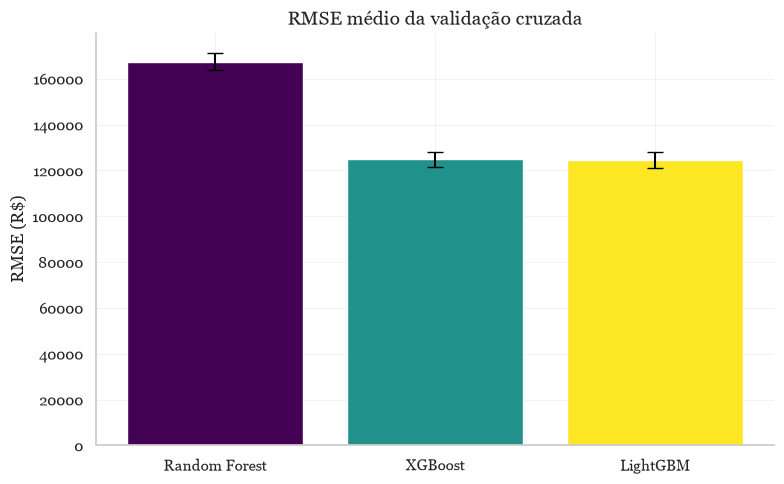

In [22]:
# RMSE médio da validação cruzada, com o desvio entre osfolds
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tabela_baseline['Modelo'], tabela_baseline['RMSE_CV_medio'],
       yerr=tabela_baseline['RMSE_CV_desvio'], capsize=6, color=['#440154', '#21918c', '#fde725'])
ax.set_title('RMSE médio da validação cruzada')
ax.set_ylabel('RMSE (R$)')
plt.tight_layout()
plt.show()

**Interpretação.** XGBoost e LightGBM erram praticamente o mesmo (cerca de R\$ 125 mil), bem menos que o Random Forest (R\$ 168 mil). As barras de desvio são pequenas (cerca de R\$ 3 a 4 mil), então essa diferença não depende de quais imóveis caíram em cada fold.

#### **4.4.2 Treino vs. validação cruzada**

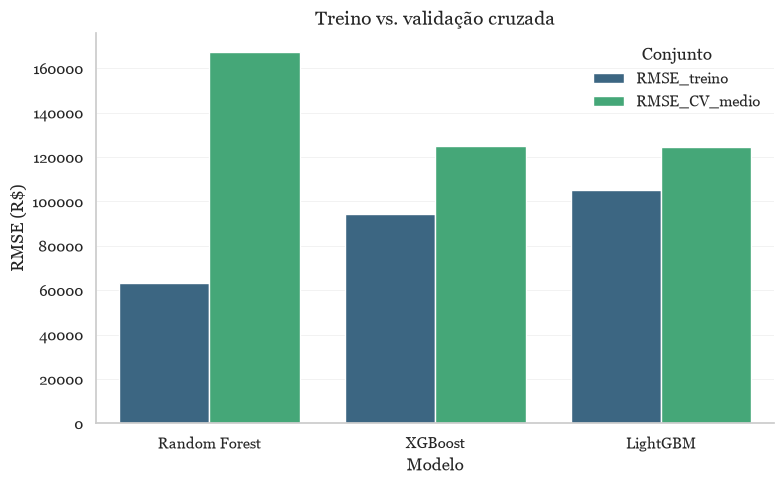

In [23]:
# RMSE de treino vs. RMSE de validação cruzada: a distância entre as barras indica overfitting
treino_vs_cv = tabela_baseline.melt(id_vars='Modelo', value_vars=['RMSE_treino', 'RMSE_CV_medio'],
                                    var_name='Conjunto', value_name='RMSE')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=treino_vs_cv, x='Modelo', y='RMSE', hue='Conjunto', ax=ax, palette='viridis')
ax.set_title('Treino vs. validação cruzada')
ax.set_ylabel('RMSE (R$)')
plt.tight_layout()
plt.show()

**Interpretação.** O Random Forest erra R\$ 63 mil nos imóveis que viu no treino, mas R\$ 168 mil na validação cruzada, uma diferença de 62% do erro de validação: é um sinal claro de **overfitting**, porque ele praticamente decora os dados de treino. No XGBoost (24%) e no LightGBM (16%) essa distância é bem menor, e eles generalizam melhor. Não há sinal de **underfitting**: nenhum modelo erra muito no próprio treino.

#### **4.4.3 Tempo de treinamento**

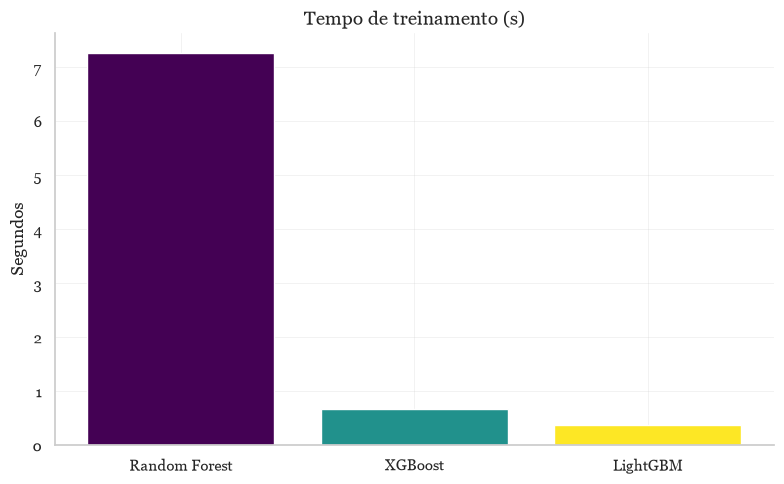

In [24]:
# Tempo de treinamento de cada modelo
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tabela_baseline['Modelo'], tabela_baseline['Tempo_treino_s'], color=['#440154', '#21918c', '#fde725'])
ax.set_title('Tempo de treinamento (s)')
ax.set_ylabel('Segundos')
plt.tight_layout()
plt.show()

**Interpretação.** O Random Forest leva cerca de 7 segundos para treinar, contra menos de 1 segundo dos modelos de boosting. Além de errar mais, ele é o mais caro, o que pesa no tempo do tuning (5.1 e 5.2).

**Resposta do aluno — Exercício 5**

Explique os espaços de busca, os resultados obtidos e a comparação entre Grid Search e Optuna.

### **5.1 Grid Search: grades, melhores parâmetros e custo**

Grade 2×2×2 por modelo (árvores, complexidade e taxa de aprendizado) em $\mathcal{D}_{\mathrm{treino}}$ completo.

In [25]:
# Grid Search
GRADES = {
    'Random Forest': (RandomForestRegressor(random_state=SEMENTE, n_jobs=-1), {
        'regressor__modelo__n_estimators': [200, 400],
        'regressor__modelo__max_depth': [10, 20],
        'regressor__modelo__min_samples_leaf': [1, 4],
    }),
    'XGBoost': (XGBRegressor(tree_method='hist', random_state=SEMENTE, n_jobs=-1, verbosity=0), {
        'regressor__modelo__n_estimators': [200, 400],
        'regressor__modelo__max_depth': [4, 6],
        'regressor__modelo__learning_rate': [0.05, 0.1],
    }),
    'LightGBM': (LGBMRegressor(random_state=SEMENTE, n_jobs=-1, verbose=-1), {
        'regressor__modelo__n_estimators': [200, 400],
        'regressor__modelo__num_leaves': [31, 63],
        'regressor__modelo__learning_rate': [0.05, 0.1],
    }),
}

resultados_grid = {}
pipelines_grid = {}
buscas_grid = {}

for nome, (modelo, grade) in GRADES.items():
    n_combinacoes = int(np.prod([len(v) for v in grade.values()]))
    print(f"\n[{nome}] {n_combinacoes} combinações x {N_FOLDS} folds = {n_combinacoes * N_FOLDS} ajustes")
    t0 = time.time()
    busca = GridSearchCV(criacao_pipeline(modelo), param_grid=grade, cv=kf,
                      scoring=METRICA_CV, n_jobs=1, refit=True)
    busca.fit(X_treino, y_treino)
    tempo_busca = time.time() - t0

    melhores = {k.replace('regressor__modelo__', ''): v for k, v in busca.best_params_.items()}
    resultados_grid[nome] = {
        'Modelo': nome, 'Estratégia': 'GridSearch',
        'RMSE_treino': rmse(y_treino, busca.best_estimator_.predict(X_treino)),
        'RMSE_CV_medio': -busca.best_score_,
        'RMSE_CV_desvio': busca.cv_results_['std_test_score'][busca.best_index_],
        'Tempo_treino_s': tempo_busca, 'Hiperparametros': formatar_parametros(melhores),
    }
    pipelines_grid[nome] = busca.best_estimator_
    buscas_grid[nome] = busca
    print(f"[{nome}] {tempo_busca:.1f}s | melhores: {formatar_parametros(melhores)} | RMSE validação cruzada = R$ {-busca.best_score_:,.0f}")

tabela_grid = pd.DataFrame(resultados_grid.values())
display(tabela_grid[['Modelo', 'Hiperparametros', 'RMSE_treino', 'RMSE_CV_medio',
                     'RMSE_CV_desvio', 'Tempo_treino_s']])


[Random Forest] 8 combinações x 5 folds = 40 ajustes


[Random Forest] 279.3s | melhores: max_depth: 20, min_samples_leaf: 1, n_estimators: 400 | RMSE validação cruzada = R$ 167,263

[XGBoost] 8 combinações x 5 folds = 40 ajustes


[XGBoost] 21.3s | melhores: learning_rate: 0.1, max_depth: 4, n_estimators: 400 | RMSE validação cruzada = R$ 121,389

[LightGBM] 8 combinações x 5 folds = 40 ajustes


[LightGBM] 25.8s | melhores: learning_rate: 0.05, n_estimators: 400, num_leaves: 31 | RMSE validação cruzada = R$ 122,787


,Modelo,Hiperparametros,RMSE_treino,RMSE_CV_medio,RMSE_CV_desvio,Tempo_treino_s
0,Random Forest,"max_depth: 20, min_samples_leaf: 1, n_estimato...",62954.092738,167263.000624,3836.769937,279.300444
1,XGBoost,"learning_rate: 0.1, max_depth: 4, n_estimators...",105424.187500,121388.939062,3462.052005,21.292059
2,LightGBM,"learning_rate: 0.05, n_estimators: 400, num_le...",104445.675795,122787.017668,3257.874460,25.759310


#### **5.1.1 Grid Search — erro de cada combinação por modelo**

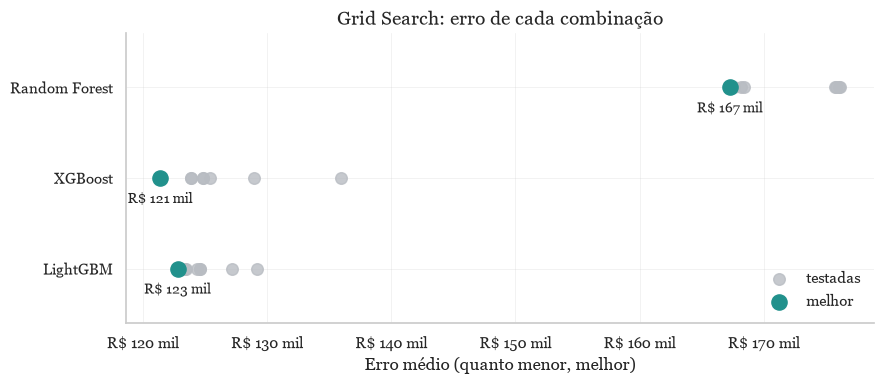

In [26]:
# Erro de todas as combinações testadas no Grid Search (cv_results_)
def plotar_grid(ax):
    for i, nome in enumerate(['Random Forest', 'XGBoost', 'LightGBM']):
        # Sinal invertido porque o sklearn guarda o erro como negativo
        erros = -buscas_grid[nome].cv_results_['mean_test_score']
        ax.scatter(erros, [i] * len(erros), s=70, color='#b8bcc2', alpha=0.8, zorder=2,
                   label='testadas' if i == 0 else None)
        # Melhor combinação em destaque, com o valor escrito embaixo
        ax.scatter(erros.min(), i, s=120, color='#21918c', zorder=3,
                   label='melhor' if i == 0 else None)
        ax.annotate(f'R$ {erros.min() / 1e3:,.0f} mil', (erros.min(), i), xytext=(0, -18),
                    textcoords='offset points', ha='center', fontsize=10)
    ax.set_yticks(range(3), ['Random Forest', 'XGBoost', 'LightGBM'])
    ax.set_ylim(2.6, -0.6)
    # Eixo em milhares de reais pra facilitar a leitura
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'R$ {v / 1e3:.0f} mil'))

fig, ax = plt.subplots(figsize=(9, 4))
plotar_grid(ax)
ax.set_title('Grid Search: erro de cada combinação')
ax.set_xlabel('Erro médio (quanto menor, melhor)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretação.** Os três grupos de pontos ficam bem separados: o Random Forest erra uns R\$ 45 mil a mais que os outros em qualquer combinação. Dentro de cada modelo, os pontos ficam próximos, ou seja, mudar os hiperparâmetros da grade altera pouco o erro. As melhores combinações foram XGBoost (R\$ 121 mil), LightGBM (R\$ 123 mil) e Random Forest (R\$ 167 mil).

### **5.2 Optuna: espaço de busca, 20 tentativas e revalidação**

20 testes com TPE numa subamostra de 10 mil linhas. O melhor resultado é revalidado no treino completo com os mesmos folds.

In [27]:
# 5.2 — Optuna
# busca em uma amostra de 10k linhas; foi a melhor config revalidada em D_treino completo
X_treino_sub = X_treino.sample(n=10000, random_state=SEMENTE)
y_treino_sub = y_treino.loc[X_treino_sub.index]
kf_optuna = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMENTE)
N_TENTATIVAS = 20

def espaco_rf(tentativa):
    return dict(
        n_estimators=tentativa.suggest_int('n_estimators', 100, 500, step=50),
        max_depth=tentativa.suggest_int('max_depth', 5, 30),
        min_samples_leaf=tentativa.suggest_int('min_samples_leaf', 1, 10),
        max_features=tentativa.suggest_float('max_features', 0.3, 1.0),
    )

def espaco_xgb(tentativa):
    return dict(
        n_estimators=tentativa.suggest_int('n_estimators', 100, 500, step=50),
        max_depth=tentativa.suggest_int('max_depth', 3, 10),
        # log=True: testa mais valores pequenos, onde a taxa de aprendizado costuma ser melhor
        learning_rate=tentativa.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=tentativa.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=tentativa.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=tentativa.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
    )

def espaco_lgbm(tentativa):
    return dict(
        n_estimators=tentativa.suggest_int('n_estimators', 100, 500, step=50),
        num_leaves=tentativa.suggest_int('num_leaves', 15, 127),
        learning_rate=tentativa.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=tentativa.suggest_float('subsample', 0.6, 1.0),
        # Fixo em 1 pra o subsample funcionar no LightGBM
        subsample_freq=1,
        colsample_bytree=tentativa.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=tentativa.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
    )

CONFIGURACAO_OPTUNA = {
    'Random Forest': (RandomForestRegressor, espaco_rf, dict(random_state=SEMENTE, n_jobs=-1)),
    'XGBoost': (XGBRegressor, espaco_xgb,
                dict(tree_method='hist', random_state=SEMENTE, n_jobs=-1, verbosity=0)),
    'LightGBM': (LGBMRegressor, espaco_lgbm, dict(random_state=SEMENTE, n_jobs=-1, verbose=-1)),
}

resultados_optuna = {}
pipelines_optuna = {}
estudos = {}

for nome, (ClasseModelo, espaco, fixos) in CONFIGURACAO_OPTUNA.items():
    def objetivo(tentativa):
        pipe = criacao_pipeline(ClasseModelo(**espaco(tentativa), **fixos))
        notas = cross_val_score(pipe, X_treino_sub, y_treino_sub, cv=kf_optuna, scoring=METRICA_CV)
        # O Optuna minimiza esse valor: o erro médio da validação cruzada na amostra
        return -notas.mean()

    t0 = time.time()
    estudo = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEMENTE))
    estudo.optimize(objetivo, n_trials=N_TENTATIVAS, show_progress_bar=False)
    tempo_busca = time.time() - t0
    estudos[nome] = estudo

    melhores = dict(estudo.best_params)
    if nome == 'LightGBM':
        melhores['subsample_freq'] = 1

    pipe = criacao_pipeline(ClasseModelo(**melhores, **fixos))
    t1 = time.time()
    pipe.fit(X_treino, y_treino)
    tempo_reajuste = time.time() - t1
    notas_cv = cross_val_score(pipe, X_treino, y_treino, cv=kf, scoring=METRICA_CV)

    resultados_optuna[nome] = {
        'Modelo': nome, 'Estratégia': 'Optuna',
        'RMSE_treino': rmse(y_treino, pipe.predict(X_treino)),
        'RMSE_CV_medio': -notas_cv.mean(), 'RMSE_CV_desvio': notas_cv.std(),
        'Tempo_treino_s': tempo_busca + tempo_reajuste, 'Hiperparametros': formatar_parametros(estudo.best_params),
    }
    pipelines_optuna[nome] = pipe
    print(f"[{nome}] busca {tempo_busca:.1f}s | melhor RMSE (subamostra)=R$ {estudo.best_value:,.0f} "
          f"| RMSE validação cruzada em D_treino completo = R$ {-notas_cv.mean():,.0f}")
    print(f"    melhores hiperparâmetros: {formatar_parametros(estudo.best_params)}")

tabela_optuna = pd.DataFrame(resultados_optuna.values())
display(tabela_optuna[['Modelo', 'Hiperparametros', 'RMSE_treino', 'RMSE_CV_medio',
                       'RMSE_CV_desvio', 'Tempo_treino_s']])

[Random Forest] busca 144.8s | melhor RMSE (subamostra)=R$ 178,679 | RMSE validação cruzada em D_treino completo = R$ 168,463
    melhores hiperparâmetros: n_estimators: 500, max_depth: 26, min_samples_leaf: 1, max_features: 0.4816


[XGBoost] busca 41.7s | melhor RMSE (subamostra)=R$ 124,138 | RMSE validação cruzada em D_treino completo = R$ 120,812
    melhores hiperparâmetros: n_estimators: 450, max_depth: 3, learning_rate: 0.1382, subsample: 0.9244, colsample_bytree: 0.9683, reg_lambda: 1.264


[LightGBM] busca 29.7s | melhor RMSE (subamostra)=R$ 130,720 | RMSE validação cruzada em D_treino completo = R$ 124,740
    melhores hiperparâmetros: n_estimators: 200, num_leaves: 23, learning_rate: 0.1258, subsample: 0.7197, colsample_bytree: 0.8877, reg_lambda: 0.3059


,Modelo,Hiperparametros,RMSE_treino,RMSE_CV_medio,RMSE_CV_desvio,Tempo_treino_s
0,Random Forest,"n_estimators: 500, max_depth: 26, min_samples_...",63048.880383,168462.995922,4600.837451,155.195062
1,XGBoost,"n_estimators: 450, max_depth: 3, learning_rate...",110659.328125,120811.814062,3420.245744,42.289102
2,LightGBM,"n_estimators: 200, num_leaves: 23, learning_ra...",108632.846711,124740.055900,5675.727762,30.036877


#### **5.2.1 Optuna — Random Forest**

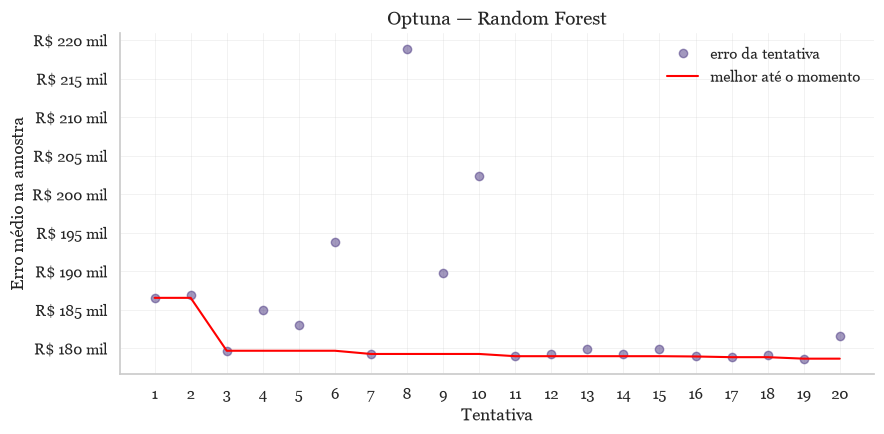

In [28]:
# Histórico de otimização do Optuna
def plotar_optuna(nome):
    valores = [t.value for t in estudos[nome].trials]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1, len(valores) + 1), valores, 'o', alpha=0.5, label='erro da tentativa')
    # Linha vermelha: menor erro encontrado até cada tentativa
    ax.plot(range(1, len(valores) + 1), np.minimum.accumulate(valores), color='red',
            label='melhor até o momento')
    ax.set_title(f'Optuna — {nome}')
    ax.set_xlabel('Tentativa')
    ax.set_ylabel('Erro médio na amostra')
    ax.set_xticks(range(1, len(valores) + 1))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'R$ {v / 1e3:.0f} mil'))
    ax.legend()
    plt.tight_layout()
    plt.show()

plotar_optuna('Random Forest')

#### **5.2.2 Optuna — XGBoost**

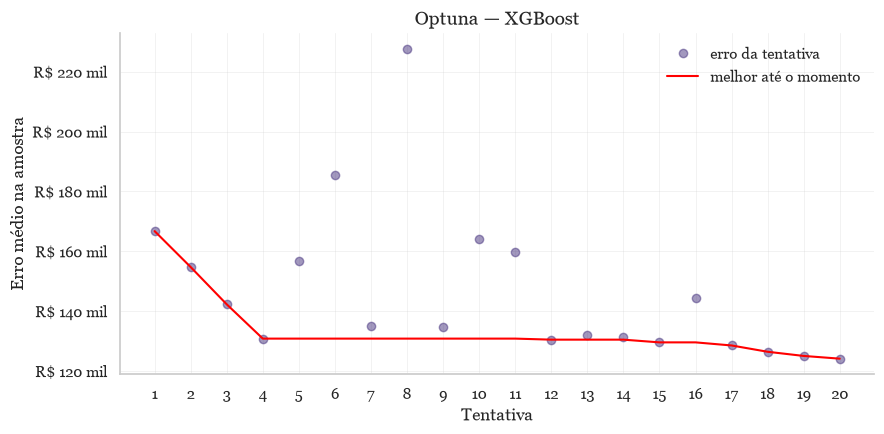

In [29]:
plotar_optuna('XGBoost')

#### **5.2.3 Optuna — LightGBM**

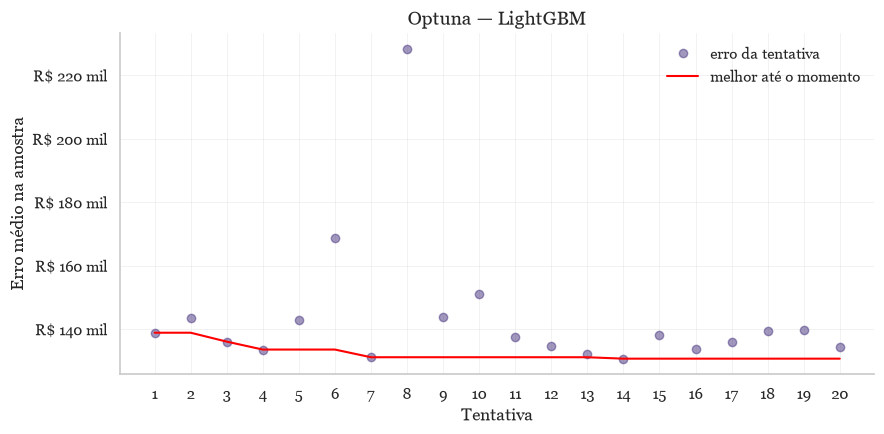

In [30]:
plotar_optuna('LightGBM')

**Interpretação.** Nos três modelos, a linha de melhor resultado cai rápido nas primeiras tentativas e depois se estabiliza: o Optuna encontra uma boa região cedo e passa a refiná-la. Cada gráfico tem a sua própria escala; comparando os valores, o XGBoost chegou ao menor erro na amostra (R\$ 124 mil), seguido do LightGBM (R\$ 131 mil) e do Random Forest (R\$ 179 mil). Reavaliados no treino completo, os erros ficaram em R\$ 121 mil, R\$ 125 mil e R\$ 168 mil.

### **5.3 Grid Search vs. Optuna: qualidade, custo e estabilidade**

RMSE, estabilidade entre folds e custo das duas estratégias.

**Por que o Optuna é mais eficiente.** O Grid Search testa todas as combinações de uma grade fixa (aqui, 8 combinações × 5 folds = 40 treinos por modelo) e nunca testa valores fora dela. O Optuna aprende com as próprias tentativas: olha quais combinações deram menor erro e escolhe a próxima perto delas. Assim, com poucas tentativas, ele explora valores que uma grade não cobriria.

Nos resultados abaixo, a diferença de RMSE entre as duas estratégias ficou abaixo de um desvio-padrão entre folds nos três modelos (Grid Search um pouco melhor no Random Forest e no LightGBM; Optuna no XGBoost). Ou seja, nesta base o ajuste de hiperparâmetros quase não muda o resultado, e a escolha final (6.1) considera também estabilidade e custo.

In [31]:
# Tabela de Vizualização do Grid Search x Optuna
comparativo = tabela_grid[['Modelo', 'RMSE_CV_medio', 'RMSE_CV_desvio', 'Tempo_treino_s']].merge(
    tabela_optuna[['Modelo', 'RMSE_CV_medio', 'RMSE_CV_desvio', 'Tempo_treino_s']],
    on='Modelo', suffixes=('_Grid', '_Optuna'))
comparativo['Diferenca_RMSE (Grid - Optuna)'] = (
    comparativo['RMSE_CV_medio_Grid'] - comparativo['RMSE_CV_medio_Optuna'])
comparativo['Diferenca_em_desvios'] = (
    comparativo['Diferenca_RMSE (Grid - Optuna)'] / comparativo['RMSE_CV_desvio_Grid'])
display(comparativo)

tempos = pd.concat([tabela_grid, tabela_optuna])[['Modelo', 'Estratégia', 'Tempo_treino_s']]

,Modelo,RMSE_CV_medio_Grid,RMSE_CV_desvio_Grid,Tempo_treino_s_Grid,RMSE_CV_medio_Optuna,RMSE_CV_desvio_Optuna,Tempo_treino_s_Optuna,Diferenca_RMSE (Grid - Optuna),Diferenca_em_desvios
0,Random Forest,167263.000624,3836.769937,279.300444,168462.995922,4600.837451,155.195062,-1199.995298,-0.312762
1,XGBoost,121388.939062,3462.052005,21.292059,120811.814062,3420.245744,42.289102,577.125000,0.166700
2,LightGBM,122787.017668,3257.874460,25.759310,124740.055900,5675.727762,30.036877,-1953.038232,-0.599482


#### **5.3.1 Custo computacional por modelo e estratégia**

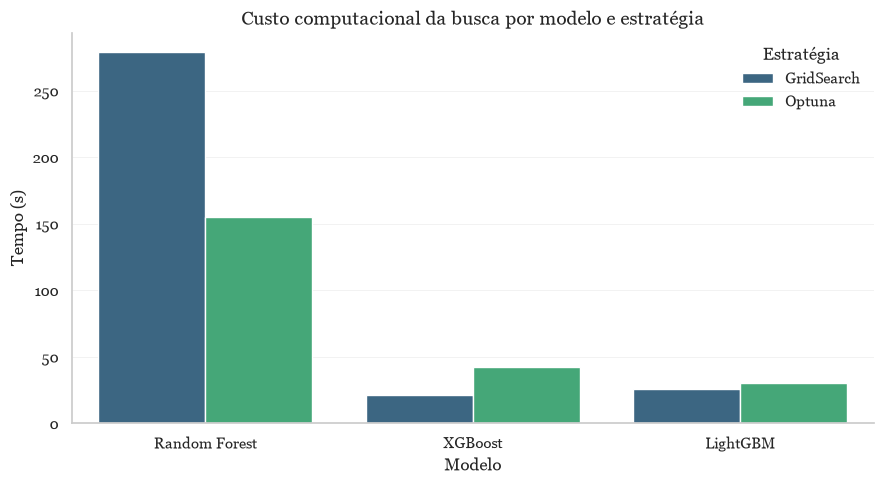

In [32]:
# Tempo de busca por modelo e estratégia
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=tempos, x='Modelo', y='Tempo_treino_s', hue='Estratégia', ax=ax, palette='viridis')
ax.set_title('Custo computacional da busca por modelo e estratégia')
ax.set_ylabel('Tempo (s)')
plt.tight_layout()
plt.show()

**Interpretação.** O Optuna só foi mais rápido no Random Forest (cerca de 155 s contra 279 s do Grid Search), em que cada treino é caro e testar menos combinações compensa. No XGBoost e no LightGBM, que treinam em segundos, a grade pequena de 8 combinações saiu mais barata que as 20 tentativas do Optuna mais o retreino no treino completo. Como a qualidade das duas estratégias foi equivalente, a vantagem do Optuna aparece nos modelos mais caros e em espaços de busca maiores.

**Resposta do aluno — Exercício 6**

Justifique a escolha do modelo final e interprete as evidências de overfitting, underfitting e importância das variáveis.

### **6.1 Tabela das 9 configurações e escolha do modelo final**

Escolha pelo menor RMSE de validação cruzada.

In [33]:
# Configurações do melhor modelo de cada estratégia
tabela_final = pd.concat([tabela_baseline, tabela_grid, tabela_optuna], ignore_index=True)
tabela_final['Gap_CV_menos_treino'] = tabela_final['RMSE_CV_medio'] - tabela_final['RMSE_treino']
tabela_final = tabela_final.sort_values('RMSE_CV_medio').reset_index(drop=True)

display(tabela_final[['Modelo', 'Estratégia', 'RMSE_treino', 'RMSE_CV_medio', 'RMSE_CV_desvio',
                      'Gap_CV_menos_treino', 'Tempo_treino_s', 'Hiperparametros']]
        .style.format({'RMSE_treino': 'R$ {:,.0f}', 'RMSE_CV_medio': 'R$ {:,.0f}',
                       'RMSE_CV_desvio': 'R$ {:,.0f}', 'Gap_CV_menos_treino': 'R$ {:,.0f}',
                       'Tempo_treino_s': '{:.1f}'}))

# menor RMSE de validação cruzada (sem usar o teste)
linha_campea = tabela_final.iloc[0]
nome_campeao = linha_campea['Modelo']
estrategia_campea = linha_campea['Estratégia']
pipelines_por_estrategia = {'Baseline': pipelines_baseline, 'GridSearch': pipelines_grid,
                            'Optuna': pipelines_optuna}
pipeline_campeao = pipelines_por_estrategia[estrategia_campea][nome_campeao]

segunda = tabela_final.iloc[1]
print(f"Modelo escolhido: {nome_campeao} ({estrategia_campea}) — "
      f"RMSE validação cruzada = R$ {linha_campea['RMSE_CV_medio']:,.0f} (+/- {linha_campea['RMSE_CV_desvio']:,.0f})")
print(f"Segunda colocada: {segunda['Modelo']} ({segunda['Estratégia']}) — "
      f"RMSE validação cruzada = R$ {segunda['RMSE_CV_medio']:,.0f}; diferença de "
      f"{(segunda['RMSE_CV_medio'] - linha_campea['RMSE_CV_medio']) / linha_campea['RMSE_CV_desvio']:.2f} "
      f"desvios-padrão entre folds")

,Modelo,Estratégia,RMSE_treino,RMSE_CV_medio,RMSE_CV_desvio,Gap_CV_menos_treino,Tempo_treino_s,Hiperparametros
0,XGBoost,Optuna,"R$ 110,659","R$ 120,812","R$ 3,420","R$ 10,152",42.3,"n_estimators: 450, max_depth: 3, learning_rate: 0.1382, subsample: 0.9244, colsample_bytree: 0.9683, reg_lambda: 1.264"
1,XGBoost,GridSearch,"R$ 105,424","R$ 121,389","R$ 3,462","R$ 15,965",21.3,"learning_rate: 0.1, max_depth: 4, n_estimators: 400"
2,LightGBM,GridSearch,"R$ 104,446","R$ 122,787","R$ 3,258","R$ 18,341",25.8,"learning_rate: 0.05, n_estimators: 400, num_leaves: 31"
3,LightGBM,Baseline,"R$ 105,272","R$ 124,582","R$ 3,529","R$ 19,311",0.4,"n_estimators: 200, num_leaves: 31, learning_rate: 0.1, min_child_samples: 20"
4,LightGBM,Optuna,"R$ 108,633","R$ 124,740","R$ 5,676","R$ 16,107",30.0,"n_estimators: 200, num_leaves: 23, learning_rate: 0.1258, subsample: 0.7197, colsample_bytree: 0.8877, reg_lambda: 0.3059"
5,XGBoost,Baseline,"R$ 94,418","R$ 124,841","R$ 3,123","R$ 30,423",0.7,"n_estimators: 200, max_depth: 6, learning_rate: 0.1, tree_method: hist"
6,Random Forest,GridSearch,"R$ 62,954","R$ 167,263","R$ 3,837","R$ 104,309",279.3,"max_depth: 20, min_samples_leaf: 1, n_estimators: 400"
7,Random Forest,Baseline,"R$ 63,054","R$ 167,516","R$ 3,868","R$ 104,463",7.3,"n_estimators: 200, max_depth: None, min_samples_leaf: 1, max_features: 1"
8,Random Forest,Optuna,"R$ 63,049","R$ 168,463","R$ 4,601","R$ 105,414",155.2,"n_estimators: 500, max_depth: 26, min_samples_leaf: 1, max_features: 0.4816"


Modelo escolhido: XGBoost (Optuna) — RMSE validação cruzada = R$ 120,812 (+/- 3,420)
Segunda colocada: XGBoost (GridSearch) — RMSE validação cruzada = R$ 121,389; diferença de 0.17 desvios-padrão entre folds


#### **6.1.1 RMSE médio de validação cruzada das 9 configurações**

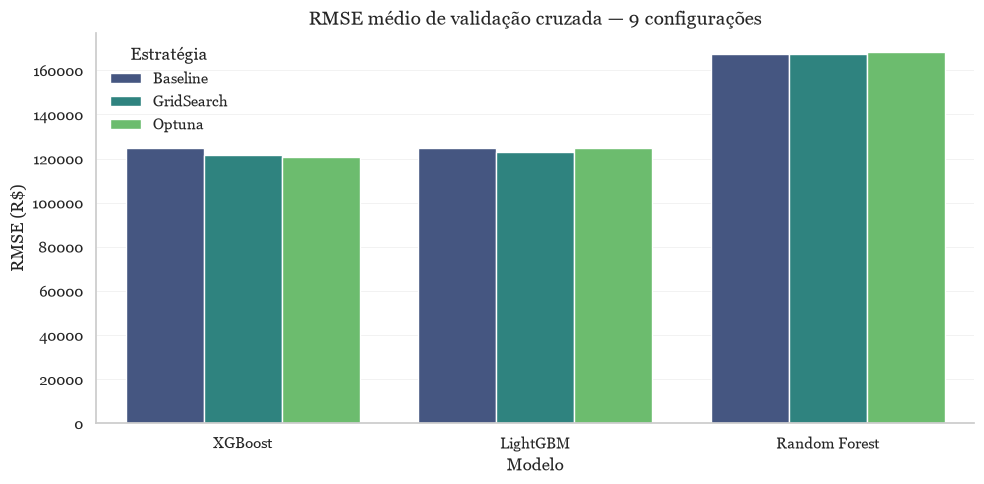

In [34]:
# RMSE médio de validação cruzada por modelo e estratégia
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tabela_final, x='Modelo', y='RMSE_CV_medio', hue='Estratégia',
            hue_order=['Baseline', 'GridSearch', 'Optuna'], palette='viridis', ax=ax)
ax.set_title('RMSE médio de validação cruzada — 9 configurações')
ax.set_ylabel('RMSE (R$)')
plt.tight_layout()
plt.show()

**Interpretação.** A configuração escolhida foi o **XGBoost ajustado com Optuna**, que teve o menor erro médio de validação cruzada (R\$ 120.812). A segunda colocada, o XGBoost do Grid Search (R\$ 121.389), ficou a apenas 0,17 desvio-padrão, então as duas são praticamente equivalentes. O XGBoost com Optuna também tem a menor distância entre treino e validação cruzada (R\$ 10 mil), o que reforça a escolha. As três configurações de Random Forest ficaram nas últimas posições, com cerca de R\$ 168 mil.

### **6.2 Curva de aprendizado: overfitting ou boa generalização?**

RMSE de treino e de validação usando de 10% a 100% do treino.

In [35]:
# 6.2 — Curva de aprendizado
tamanhos_treino, notas_treino, notas_validacao = learning_curve(
    pipeline_campeao, X_treino, y_treino, cv=kf, scoring=METRICA_CV,
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=1,
)
rmse_treino_curva = -notas_treino.mean(axis=1)
rmse_validacao_curva = -notas_validacao.mean(axis=1)



curva = pd.DataFrame({'n_treino': tamanhos_treino, 'RMSE_treino': rmse_treino_curva,
                      'RMSE_CV': rmse_validacao_curva, 'Gap': rmse_validacao_curva - rmse_treino_curva})
display(curva.style.format({'RMSE_treino': 'R$ {:,.0f}', 'RMSE_CV': 'R$ {:,.0f}', 'Gap': 'R$ {:,.0f}'}))
print(f"Gap final (validação cruzada - treino) = R$ {curva['Gap'].iloc[-1]:,.0f} "
      f"({curva['Gap'].iloc[-1] / curva['RMSE_CV'].iloc[-1]:.1%} do RMSE de validação cruzada)")

,n_treino,RMSE_treino,RMSE_CV,Gap
0,3061,"R$ 73,089","R$ 143,642","R$ 70,553"
1,8570,"R$ 94,250","R$ 128,385","R$ 34,135"
2,14080,"R$ 100,898","R$ 124,398","R$ 23,500"
3,19590,"R$ 105,162","R$ 123,709","R$ 18,547"
4,25100,"R$ 106,572","R$ 122,157","R$ 15,585"
5,30610,"R$ 108,931","R$ 120,396","R$ 11,466"


Gap final (validação cruzada - treino) = R$ 11,466 (9.5% do RMSE de validação cruzada)


#### **6.2.1 Curva de aprendizado**

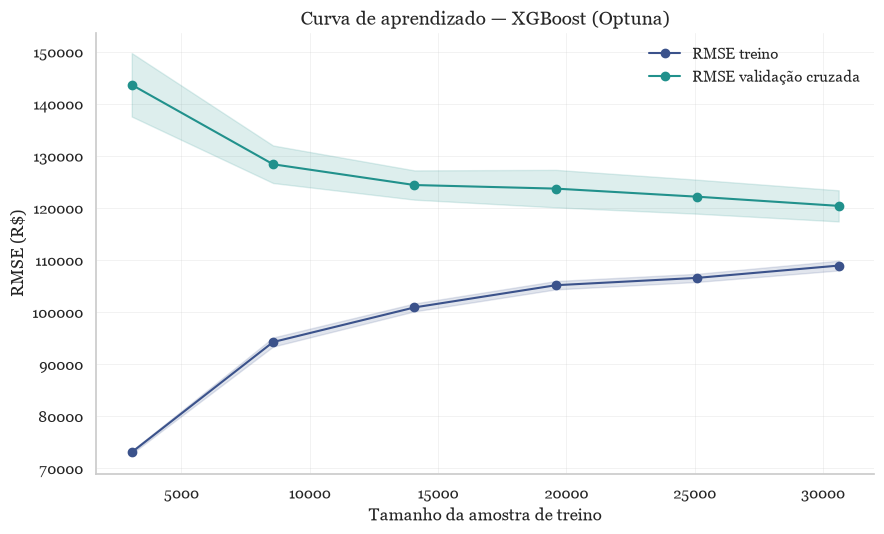

In [36]:
# RMSE de treino e de validação por tamanho da amostra
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(tamanhos_treino, rmse_treino_curva, 'o-', label='RMSE treino', color='#3b528b')
ax.plot(tamanhos_treino, rmse_validacao_curva, 'o-', label='RMSE validação cruzada', color='#21918c')
ax.fill_between(tamanhos_treino, rmse_treino_curva - notas_treino.std(axis=1),
                rmse_treino_curva + notas_treino.std(axis=1), alpha=0.15, color='#3b528b')
ax.fill_between(tamanhos_treino, rmse_validacao_curva - notas_validacao.std(axis=1),
                rmse_validacao_curva + notas_validacao.std(axis=1), alpha=0.15, color='#21918c')
ax.set_xlabel('Tamanho da amostra de treino')
ax.set_ylabel('RMSE (R$)')
ax.set_title(f'Curva de aprendizado — {nome_campeao} ({estrategia_campea})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação.** Com mais dados, o erro de validação cai (de R\$ 144 mil para R\$ 120 mil) e o de treino sobe, e as duas curvas se aproximam. A distância final é de R\$ 11 mil, só 9,5% do erro de validação: sinal de **boa generalização**, sem overfitting relevante. A curva de validação ainda cai levemente no fim, então mais dados poderiam melhorar um pouco o modelo.

### **6.3 Importância das variáveis e análise de resíduos**

Importância das variáveis e resíduos calculados com as previsões da validação cruzada.

In [37]:
# Importância das variáveis
modelo_interno = pipeline_campeao.regressor_.named_steps['modelo']
nomes_variaveis = [n.split('__', 1)[-1] for n in
                  pipeline_campeao.regressor_.named_steps['preprocessador'].get_feature_names_out()]

importancias = (pd.Series(modelo_interno.feature_importances_, index=nomes_variaveis)
                .sort_values(ascending=False))
importancias = importancias / importancias.sum()


print(importancias.head(10).apply(lambda v: f"{v:.1%}"))

bairro_codificado         37.6%
condominio_brl_monthly    16.9%
area_util_m2              15.1%
condition_reformado        5.0%
to_faria_lima_km           4.2%
condition_novo             3.1%
listing_year               3.1%
area_total_m2              2.5%
condition_seminovo         1.8%
sun_facing_face_sul        1.5%
dtype: object


#### **6.3.1 Importância das variáveis**

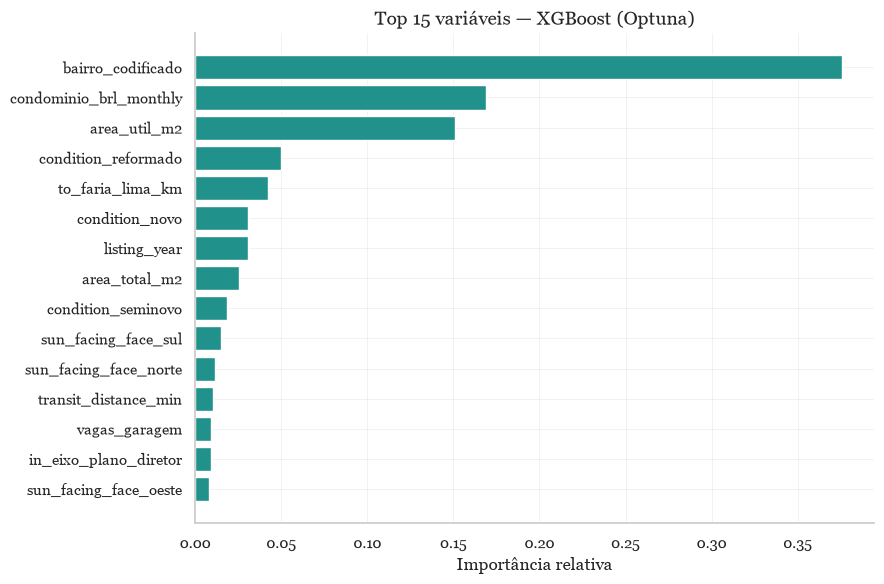

In [38]:
# As 15 variáveis mais importantes do modelo escolhido
fig, ax = plt.subplots(figsize=(9, 6))
principais = importancias.head(15)
ax.barh(principais.index[::-1], principais.values[::-1], color='#21918c')
ax.set_title(f'Top 15 variáveis — {nome_campeao} ({estrategia_campea})')
ax.set_xlabel('Importância relativa')
plt.tight_layout()
plt.show()

**Interpretação.** O bairro é, de longe, a variável mais importante (37,6%), seguido do condomínio (16,9%) e da área útil (15,1%). Localização, tamanho e padrão, que é o que o condomínio reflete, explicam a maior parte do preço, o que é coerente com o mercado imobiliário. A conservação do imóvel (reformado ou novo) e a distância até a Faria Lima vêm em seguida.

In [39]:
# Observados vs. previstos e resíduos
prev_validacao = cross_val_predict(pipeline_campeao, X_treino, y_treino, cv=kf, n_jobs=1)
residuos = y_treino.values - prev_validacao

faixas = pd.qcut(y_treino, 5, labels=['Q1 (mais baratos)', 'Q2', 'Q3', 'Q4', 'Q5 (mais caros)'])
erro_por_faixa = pd.DataFrame({'faixa': faixas, 'erro_abs': np.abs(residuos),
                               'erro_pct': np.abs(residuos) / y_treino.values})
display(erro_por_faixa.groupby('faixa', observed=True)
        .agg(MAE=('erro_abs', 'mean'), erro_pct_mediano=('erro_pct', 'median'))
        .style.format({'MAE': 'R$ {:,.0f}', 'erro_pct_mediano': '{:.1%}'}))
print(f"RMSE das previsões da validação cruzada = R$ {rmse(y_treino, prev_validacao):,.0f} | R² = {r2_score(y_treino, prev_validacao):.4f}")

,MAE,erro_pct_mediano
faixa,,
Q1 (mais baratos),"R$ 15,807",7.3%
Q2,"R$ 29,465",7.3%
Q3,"R$ 46,840",7.2%
Q4,"R$ 75,931",7.3%
Q5 (mais caros),"R$ 173,224",7.5%


RMSE das previsões da validação cruzada = R$ 120,860 | R² = 0.9738


#### **6.3.2 Observados vs. previstos (previsões da validação cruzada)**

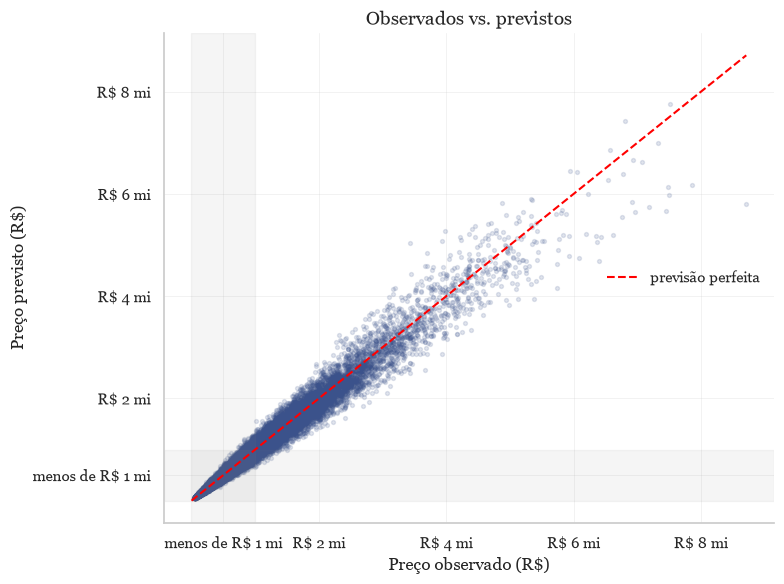

In [40]:
# Observados vs. previstos
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_treino, prev_validacao, alpha=0.15, s=8, color='#3b528b')
limites = [0, max(y_treino.max(), prev_validacao.max())]
ax.plot(limites, limites, color='red', linestyle='--', label='previsão perfeita')
ax.set_xlabel('Preço observado (R$)')
ax.set_ylabel('Preço previsto (R$)')
ax.set_title('Observados vs. previstos')
ax.legend()
eixo_em_milhoes(ax, 'x')
eixo_em_milhoes(ax, 'y')
plt.tight_layout()
plt.show()

**Interpretação.** Os pontos seguem a diagonal de previsão perfeita em toda a faixa de preços, sem tendência de errar sempre para cima ou para baixo. A dispersão aumenta nos imóveis mais caros, o que é esperado, porque o erro em reais cresce com o valor.

#### **6.3.3 Resíduos vs. previstos**

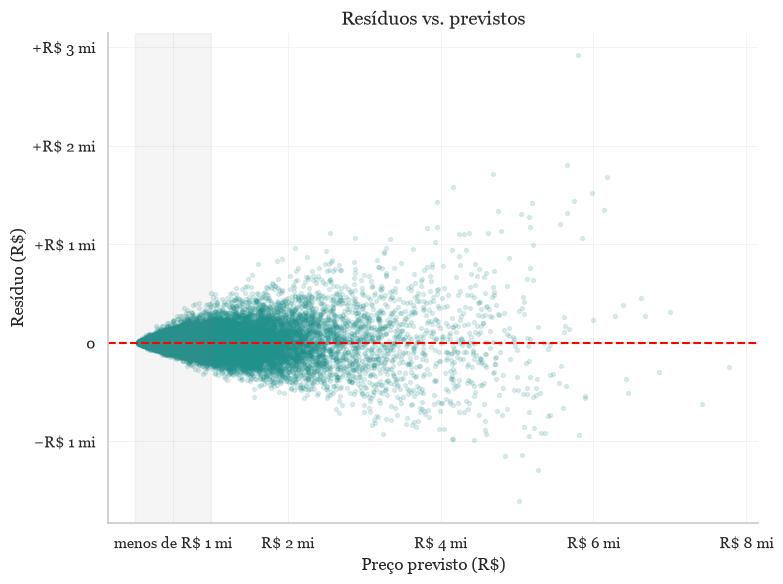

In [41]:
# Resíduos vs. previstos (previsões da validação cruzada)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(prev_validacao, residuos, alpha=0.15, s=8, color='#21918c')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Preço previsto (R$)')
ax.set_ylabel('Resíduo (R$)')
ax.set_title('Resíduos vs. previstos')
eixo_em_milhoes(ax, 'x')
eixo_residuo_em_milhoes(ax)
plt.tight_layout()
plt.show()

**Interpretação.** Os resíduos se distribuem em torno de zero, sem viés. Eles se abrem em forma de funil: o erro em reais vai de R\$ 16 mil nos imóveis mais baratos a R\$ 173 mil nos mais caros. Em termos percentuais, porém, o erro é o mesmo em todas as faixas (7,2% a 7,5%, na tabela acima), consequência de treinar em escala logarítmica.

**Resposta do aluno — Exercício 7**

Interprete o resultado do teste final, documente o teste de consistência, registre os links do GitHub e do Streamlit e prepare a síntese da solução para a apresentação oral de até 10 minutos.

### **7.1 Avaliação final no conjunto de teste**

Retreino em $\mathcal{D}_{\mathrm{treino}}$ e avaliação única em $\mathcal{D}_{\mathrm{teste}}$.

In [42]:
# 7.1 — Avaliação final
pipeline_final = pipeline_campeao
pipeline_final.fit(X_treino, y_treino)

y_prev_teste = pipeline_final.predict(X_teste)
rmse_teste = rmse(y_teste, y_prev_teste)
mae_teste = mean_absolute_error(y_teste, y_prev_teste)
r2_teste = r2_score(y_teste, y_prev_teste)

comparacao_final = pd.DataFrame({
    'Validação cruzada (D_treino)': [linha_campea['RMSE_CV_medio'],
                                     mean_absolute_error(y_treino, prev_validacao),
                                     r2_score(y_treino, prev_validacao)],
    'Teste (D_teste)': [rmse_teste, mae_teste, r2_teste],
}, index=['RMSE (R$)', 'MAE (R$)', 'R²'])
display(comparacao_final.style.format('{:,.4f}'))

diferenca_pct = (rmse_teste - linha_campea['RMSE_CV_medio']) / linha_campea['RMSE_CV_medio']
print(f"Modelo: {nome_campeao} ({estrategia_campea})")
print(f"Diferença RMSE teste vs. validação cruzada: {diferenca_pct:+.1%} "
      f"(desvio entre folds na validação cruzada: ±{linha_campea['RMSE_CV_desvio'] / linha_campea['RMSE_CV_medio']:.1%})")

,Validação cruzada (D_treino),Teste (D_teste)
RMSE (R$),"120,811.8141","114,403.0469"
MAE (R$),"68,216.0938","66,909.5547"
R²,0.9738,0.9753


Modelo: XGBoost (Optuna)
Diferença RMSE teste vs. validação cruzada: -5.3% (desvio entre folds na validação cruzada: ±2.8%)


#### **7.1.1 Valores reais vs. preditos no teste**

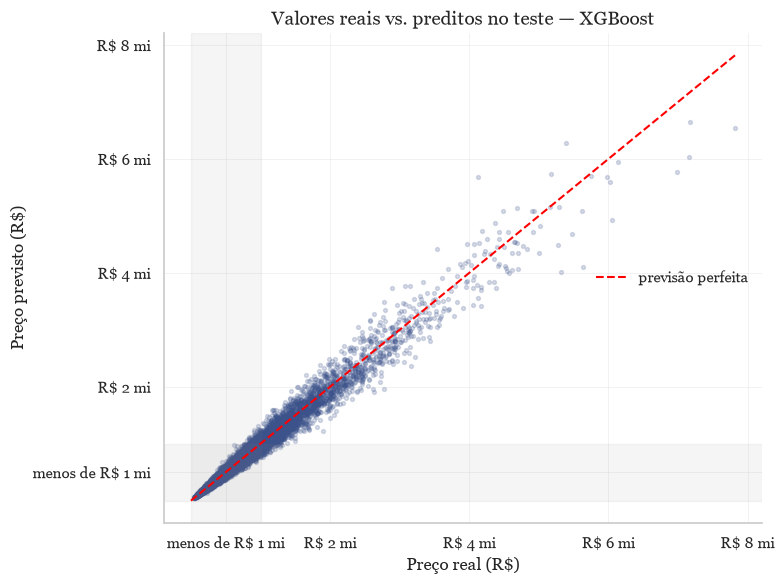

In [43]:
# Valores reais vs. preditos no conjunto de teste
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_teste, y_prev_teste, alpha=0.2, s=8, color='#3b528b')
limite = [0, max(y_teste.max(), y_prev_teste.max())]
ax.plot(limite, limite, color='red', linestyle='--', label='previsão perfeita')
ax.set_xlabel('Preço real (R$)')
ax.set_ylabel('Preço previsto (R$)')
ax.set_title(f'Valores reais vs. preditos no teste — {nome_campeao}')
ax.legend()
eixo_em_milhoes(ax, 'x')
eixo_em_milhoes(ax, 'y')
plt.tight_layout()
plt.show()

**Interpretação.** No teste, o RMSE foi de R\$ 114.403, 5,3% abaixo da validação cruzada (R\$ 120.812), com MAE e R² praticamente iguais aos da validação (R² de 0,975 contra 0,974). A generalização é compatível com o desenvolvimento. O teste ficou um pouco melhor porque o modelo final foi treinado com todo o treino, enquanto na validação cruzada cada modelo usava só 80% dele, e a curva de aprendizado (6.2) mostra que mais dados reduzem o erro. O gráfico repete o padrão da validação cruzada: pontos na diagonal e dispersão maior nos imóveis caros.

### **7.2 Teste de consistência, com melhores e piores casos**


In [44]:
# Teste de consistência
tabela_consistencia = X_teste.copy()
tabela_consistencia['y_real'] = y_teste.values
tabela_consistencia['y_previsto'] = y_prev_teste
tabela_consistencia['erro_e'] = y_teste.values - y_prev_teste
tabela_consistencia['erro_abs_%'] = np.abs(tabela_consistencia['erro_e']) / y_teste.values

idx_melhor = tabela_consistencia['erro_e'].abs().idxmin()
idx_pior = tabela_consistencia['erro_e'].abs().idxmax()
idx_aleatorios = (tabela_consistencia.drop(index=[idx_melhor, idx_pior])
                  .sample(n=3, random_state=SEMENTE).index)

amostra_consistencia = tabela_consistencia.loc[[idx_melhor, *idx_aleatorios, idx_pior]].copy()
amostra_consistencia.insert(0, 'caso', ['Bom desempenho (menor erro)', 'Aleatório',
                                        'Aleatório', 'Aleatório', 'Caso difícil (maior erro)'])

colunas_exibir = ['caso', 'bairro', 'zona', 'tier', 'property_type', 'area_util_m2',
                  'building_age', 'condition', 'y_real', 'y_previsto', 'erro_e', 'erro_abs_%']
display(amostra_consistencia[colunas_exibir].style.format({
    'y_real': 'R$ {:,.0f}', 'y_previsto': 'R$ {:,.0f}', 'erro_e': 'R$ {:,.0f}',
    'erro_abs_%': '{:.1%}', 'area_util_m2': '{:.1f}'}))

# imóveis do mesmo bairro e tier em D_treino
pior = tabela_consistencia.loc[idx_pior]
mascara_similares = (X_treino['bairro'] == pior['bairro']) & (X_treino['tier'] == pior['tier'])
preco_m2_similares = y_treino[mascara_similares] / X_treino.loc[mascara_similares, 'area_util_m2']
print(f"Caso difícil — {pior['bairro']} / {pior['tier']}: preço real R$ {pior['y_real']:,.0f}, "
      f"{pior['area_util_m2']:.0f} m² -> R$ {pior['y_real'] / pior['area_util_m2']:,.0f}/m²")
print(f"Imóveis semelhantes em D_treino ({mascara_similares.sum()}): mediana de "
      f"R$ {preco_m2_similares.median():,.0f}/m²")

,caso,bairro,zona,tier,property_type,area_util_m2,building_age,condition,y_real,y_previsto,erro_e,erro_abs_%
35607,Bom desempenho (menor erro),Vila Leopoldina,Zona Oeste,premium,1_dorm,23.8,13,necessita_reforma,"R$ 199,000","R$ 199,013",R$ -13,0.0%
20950,Aleatório,Vila Leopoldina,Zona Oeste,premium,3_dorm,106.6,23,reformado,"R$ 1,063,000","R$ 1,075,595","R$ -12,595",1.2%
7619,Aleatório,Sacomã,Zona Sul,mid,2_dorm,65.6,10,reformado,"R$ 465,000","R$ 494,874","R$ -29,874",6.4%
27994,Aleatório,Cambuci,Centro,mid,2_dorm,83.6,16,necessita_reforma,"R$ 443,000","R$ 503,660","R$ -60,660",13.7%
10482,Caso difícil (maior erro),Moema,Zona Sul,luxury,4_dorm_plus,251.2,20,reformado,"R$ 4,121,000","R$ 5,690,180","R$ -1,569,180",38.1%


Caso difícil — Moema / luxury: preço real R$ 4,121,000, 251 m² -> R$ 16,405/m²
Imóveis semelhantes em D_treino (446): mediana de R$ 19,414/m²


In [45]:
# Entradas completas (teste de paridade no Streamlit)
display(amostra_consistencia[['caso'] + COLUNAS_X + ['y_previsto']].T)

,35607,20950,7619,27994,10482
caso,Bom desempenho (menor erro),Aleatório,Aleatório,Aleatório,Caso difícil (maior erro)
lat,-23.53597,-23.54291,-23.61177,-23.5672,-23.6083
lon,-46.72222,-46.72379,-46.60457,-46.6125,-46.67108
area_util_m2,23.8,106.6,65.6,83.6,251.2
area_total_m2,29.0,129.9,78.6,106.2,319.5
floor,6,10,1,21,12
total_floors,40,25,15,25,25
dorms,1,3,2,2,4
vagas_garagem,2,2,1,1,2
year_built,2009,1997,2011,2004,2003


**Interpretação.** O melhor caso, um apartamento de 1 dormitório na Vila Leopoldina, foi previsto com erro de R\$ 13 (0,0%). Os três aleatórios erraram 1,2%, 6,4% e 13,7%, perto do erro típico do modelo. O caso difícil é um apartamento de luxo de 251 m² em Moema: o modelo previu R\$ 5,69 milhões para um anúncio de R\$ 4,12 milhões (38% acima). O anúncio saiu a R\$ 16.405/m², bem abaixo da mediana de R\$ 19.414/m² de imóveis parecidos (mesmo bairro e padrão) no treino. O modelo seguiu o padrão da região, e o imóvel é que foi anunciado abaixo dele.

### **7.3 Modelo salvo, GitHub e Streamlit**

Pipeline salvo com `pickle`, com o mapa dos bairros e as categorias válidas pro Streamlit.

- **GitHub:** [https://github.com/Ulisseswrk/Previsao-Preco-Imoveis](https://github.com/Ulisseswrk/Previsao-Preco-Imoveis)
- **Streamlit:** [https://predicaoprecoimoveis.streamlit.app/](https://predicaoprecoimoveis.streamlit.app/)

In [46]:
# Modelo salvo
codificador_bairro_ajustado = (pipeline_final.regressor_.named_steps['preprocessador']
                           .named_transformers_['codif_bairro'])

modelo_salvo = {
    'pipeline': pipeline_final,
    'mapa_bairro': codificador_bairro_ajustado.mapa_,
    'media_global_bairro': codificador_bairro_ajustado.media_global_,
    'colunas_x': COLUNAS_X,
    'colunas_numericas': COLUNAS_NUMERICAS,
    'colunas_custo': COLUNAS_CUSTO,
    'categoricas_baixa_card': CATEGORICAS_BAIXA_CARD,
    'categoricas_alta_card': CATEGORICAS_ALTA_CARD,
    'categorias': {c: sorted(X_treino[c].unique().tolist()) for c in CATEGORICAS_BAIXA_CARD + CATEGORICAS_ALTA_CARD},
    'nome_modelo': nome_campeao,
    'estrategia_tuning': estrategia_campea,
    'metricas_teste': {'RMSE': rmse_teste, 'MAE': mae_teste, 'R2': r2_teste,
                     'erro_pct_mediano': float(tabela_consistencia['erro_abs_%'].median())},
}
with open('modelo.pkl', 'wb') as f:
    pickle.dump(modelo_salvo, f)

# o Streamlit precisa da mesma classe CodificadorBairro antes do pickle.load
with open('modelo.pkl', 'rb') as f:
    modelo_recarregado = pickle.load(f)
prev_recarregado = modelo_recarregado['pipeline'].predict(amostra_consistencia[COLUNAS_X])
print("Modelo salvo em 'modelo.pkl' com as chaves:", list(modelo_salvo))
print("Previsões idênticas após recarregar:",
      np.allclose(prev_recarregado, amostra_consistencia['y_previsto'].values))

URL_GITHUB = "https://github.com/Ulisseswrk/Previsao-Preco-Imoveis"
URL_STREAMLIT = "https://predicaoprecoimoveis.streamlit.app/"

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

Modelo salvo em 'modelo.pkl' com as chaves: ['pipeline', 'mapa_bairro', 'media_global_bairro', 'colunas_x', 'colunas_numericas', 'colunas_custo', 'categoricas_baixa_card', 'categoricas_alta_card', 'categorias', 'nome_modelo', 'estrategia_tuning', 'metricas_teste']
Previsões idênticas após recarregar: True
GitHub: https://github.com/Ulisseswrk/Previsao-Preco-Imoveis
Streamlit: https://predicaoprecoimoveis.streamlit.app/
